# 05b · LeNet: 05의 합성곱을 실제 손글씨에 적용하기

**이번 질문:** 8×8 도안에서 통한 conv·pool·선형층을 28×28 실제 손글씨 6만 장에 그대로 쓰면 무엇이 달라질까요?

05번은 3×3 커널 6개와 선형층 하나로 8×8 도안 500장을 분류했습니다. 이번에는 05번의 네 함수(conv·pool의 forward·backward)를 **그대로** 가져와, padding으로 크기를 지키는 5×5 창을 **두 단** 쌓고 선형층을 셋 붙인 LeNet-5 모양의 모델을 만듭니다.
달라지는 것은 수식이 아니라 규모와 절차입니다. 파라미터 61,706개, 학습 20,000장, 에폭·미니배치·검증 정확도, 그리고 마지막에 한 번만 보는 test 보고까지 실제 학습의 순서를 밟습니다.

- 준비물: [05](05_cnn.ipynb)의 conv_forward/backward·pool·패치 행렬, [01b](../00_기초/01b_minibatch.ipynb)의 미니배치·에폭·셔플, [04](../00_기초/04_optimizers.ipynb)의 Adam·He 초기화, [15](../02_연결/15_experiments_evaluation.ipynb)의 분할·test 보고·혼동 행렬.
- 도착점: LeNet-5 모양의 NumPy CNN을 실제 MNIST에서 학습해 test 정확도를 보고하고, 학습된 커널·특성 맵과 이동에 대한 반응을 봅니다.
- 다음 연결: [06 RNN](06_rnn.ipynb)은 같은 가중치를 위치가 아니라 **시간**에 공유합니다. 이 노트북의 conv 두 단은 뒤에 나올 물체 검출([18b](../03_구조조합/18b_detection_yolo.ipynb))에서 특징을 뽑는 앞부분(백본, backbone)으로 다시 쓰입니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 층마다 출력의 한 변은 $\lfloor (H+2p-k)/s\rfloor+1$이고, $p=2$·$k=5$·$s=1$이면 크기가 유지됩니다. conv → pool → conv → pool을 지나며 28 → 28 → 14 → 10 → 5. 코드로는 `(H + 2 * p - k) // s + 1`.
2. 다섯 층의 backward는 03번의 선형층 세 식과 05번의 pool·conv backward를 **forward의 거꾸로 순서로** 부르는 것뿐입니다. 새 미분은 없습니다. `dP2 = (dZ3 @ W1.T).reshape(P2.shape)` 뒤 `pool_backward` → `conv_backward`.
3. 학습은 에폭마다 순서를 섞어 $\lceil N/B\rceil$ 스텝을 돌고, 에폭 끝마다 검증 정확도를 재며, test는 **마지막에 한 번만** 봅니다. `for idx in epoch_batches(N, 64, rng): … adam_update(p, grads, state, step)`.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/lenet_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import math                                            # math.ceil: 올림. 3절의 ⌈N/B⌉
import sys
import time                                            # time.perf_counter: 학습 시간을 재는 시계. 3절
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/lenet_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.lenet_plots import (
    plot_padding_scene, plot_feature_flow, plot_lenet_blocks, plot_lenet_trace, plot_data_plan, plot_training_result,
    plot_kernels_before_after, plot_feature_maps, plot_shift_response, plot_confusion_matrix, plot_wrong_examples,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· LeNet 준비 완료")

NumPy 2.4.6 · LeNet 준비 완료


### 📎 이 노트북의 예시: 실제 MNIST, 고정 예시 7, 손계산 격자

- **실제 MNIST.** 05번의 8×8 도안 대신 손글씨 6만 장입니다. MNIST 학습 파일 60,000장 중 **앞** 20,000장으로 학습하고, 같은 파일의 **맨 뒤** 2,000장(58,000–60,000번)을 검증에 씁니다. 두 집합은 겹치지 않습니다(15번 4절: 검증은 학습 파일에서 떼어 냅니다). test 10,000장은 5절에서 한 번만 봅니다.
- **고정 예시 7.** 00번부터 쓴 고정 예시 10장 중 7입니다. 층을 하나씩 지날 때 특성 맵이 어떻게 작아지는지(1절), 학습 뒤 커널이 무엇을 보는지(3절), 옆으로 옮기면 무엇이 변하는지(4절)를 이 한 장으로 봅니다.
- **손계산 격자.** 4×4 정수 격자에 0을 한 겹 두르고 3×3 창을 대는 작은 예로, padding이 크기를 지키는 것을 손으로 확인합니다.

> **용어**
>
> - **MNIST**: 28×28 흑백 손글씨 숫자 70,000장(학습 60,000 + test 10,000)과 정답 0–9. 값은 0(흰 종이)부터 1(진한 잉크)까지의 실수입니다. 이미지 분류의 기본 연습 문제라 05번 도안의 결과와 실제 손글씨의 결과를 견주기에 좋습니다.
> - **학습·검증·test 집합(train·validation·test)**: 가중치를 갱신하는 데 쓰는 집합, 진행을 보고 설정을 고르는 데 쓰는 집합, 마지막에 한 번만 보고하는 집합. 15번의 규칙대로 test는 학습 중 보지 않습니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `load_mnist(flatten=False)`: 이미지를 `(N, 1, 28, 28)` = (이미지 수, 채널 1, 높이, 너비)로 돌려줍니다. 05번 1절의 텐서 모양 $(N, C, H, W)$입니다.
> - `mnist_X_all[-2000:]`: 뒤에서 2,000장. 음수로 시작하는 슬라이스는 끝에서 셉니다.
> - `mnist_examples[7][None, None]`: `(28, 28)` 한 장 앞에 길이 1인 축 두 개를 붙여 `(1, 1, 28, 28)` 배치 모양으로. 05번 1절의 `grid_X[None, None]`과 같습니다.
> - `np.bincount(y, minlength=10)`: 0–9가 각각 몇 번 나오는지 센 길이 10의 배열.

In [2]:
mnist_X_all, mnist_y_all, mnist_X_test, mnist_y_test = load_mnist(flatten=False, download=True)   # (60000, 1, 28, 28), (60000,), (10000, 1, 28, 28), (10000,)
mnist_X_train, mnist_y_train = mnist_X_all[:20000], mnist_y_all[:20000]            # (20000, 1, 28, 28), (20000,): 학습 집합. 앞 20,000장
mnist_X_valid, mnist_y_valid = mnist_X_all[-2000:], mnist_y_all[-2000:]            # (2000, 1, 28, 28), (2000,): 검증 집합. 60,000장 중 맨 뒤 2,000장
mnist_examples, mnist_labels = load_examples(download=True)                        # (10, 28, 28) 고정 예시 10장, (10,) 정답
mnist_7 = mnist_examples[7][None, None]                                            # (1, 1, 28, 28): 예시 7을 배치 모양으로
grid_X = np.array([[1., 2., 0., 1.],
                   [0., 1., 2., 0.],
                   [1., 0., 1., 2.],
                   [2., 1., 0., 1.]])                                              # (4, 4): 손계산용 입력
grid_K = np.array([[1., 0., -1.],
                   [1., 0., -1.],
                   [1., 0., -1.]])                                                 # (3, 3): 커널. 창의 왼쪽 열 − 오른쪽 열 (05번과 같음)
print("학습", mnist_X_train.shape, "· 검증", mnist_X_valid.shape, "· test", mnist_X_test.shape, "· 예시 7", mnist_7.shape)
print("학습 집합의 숫자별 장수:", np.bincount(mnist_y_train, minlength=10))

학습 (20000, 1, 28, 28) · 검증 (2000, 1, 28, 28) · test (10000, 1, 28, 28) · 예시 7 (1, 1, 28, 28)
학습 집합의 숫자별 장수: [1994 2281 1929 2076 1945 1775 1971 2093 1922 2014]


### 📎 05번의 네 함수를 다시 적습니다

이 노트북은 05번 없이 혼자 실행되도록 05번 2·3·4절의 `conv_forward`·`conv_backward`·`pool_forward`·`pool_backward`를 그대로 다시 적습니다. 네 함수 모두 stride·padding과 $(N, C, H, W)$ 배치를 이미 지원하므로 고칠 것이 없습니다.
설명(패치 행렬 $P$, 겹친 자리의 `+=`, 구역 안쪽 두 축)은 05번에 있으니 아래 다섯 셀은 실행만 하고 넘어가도 됩니다. 마지막 셀은 05번의 손계산 두 개로 네 함수가 제대로 들어왔는지만 봅니다.

In [3]:
def conv_forward(X, K, b, stride=1, padding=0):
    """패치 행렬로 합성곱 (05번 2절): 모든 창을 행으로 쌓은 P에 대해 Y_rows = P K_flatᵀ + b, 그다음 (N, F, oh, ow)로 접습니다.
    X: (N, C, H, W), K: (F, C, kh, kw), b: (F,) → (Y: (N, F, oh, ow), cache: backward용 (X.shape, K, P, stride, padding))."""
    N, C, H, W = X.shape
    F, Ck, kh, kw = K.shape
    assert C == Ck, "커널의 입력 채널 수는 X의 채널 수와 같아야 합니다"
    assert stride >= 1, "stride는 1 이상이어야 합니다"
    assert padding >= 0, "padding은 0 이상이어야 합니다"
    oh = (H + 2 * padding - kh) // stride + 1               # 출력 크기 (05번 1절 공식)
    ow = (W + 2 * padding - kw) // stride + 1
    assert oh > 0, "커널이 입력보다 크면 출력 높이가 0이 됩니다"
    assert ow > 0, "커널이 입력보다 크면 출력 너비가 0이 됩니다"
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    patches = np.empty((N, oh, ow, C, kh, kw))              # 자리마다 창 하나 (C, kh, kw)
    for i in range(oh):
        for j in range(ow):
            patches[:, i, j] = Xp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw]   # 모든 이미지의 (i, j) 창
    P = patches.reshape(N * oh * ow, -1)                    # (N·oh·ow, C·kh·kw): 패치 행렬
    rows = P @ K.reshape(F, -1).T + b                       # (N·oh·ow, F): 행렬곱 한 번 + 편향
    Y = rows.reshape(N, oh, ow, F).transpose(0, 3, 1, 2)    # (N, F, oh, ow): 채널 축을 앞으로
    cache = (X.shape, K, P, stride, padding)
    return Y, cache

In [4]:
def conv_backward(dY, cache):
    """합성곱 backward (05번 3절): G = dY를 행으로 편 뒤 dK = Gᵀ P, db = Σ_rows G, dP = G K_flat, 그리고 dP를 창 자리마다 입력에 **더해** dX.
    dY: (N, F, oh, ow), cache: conv_forward의 것 → (dX: (N, C, H, W), dK: (F, C, kh, kw), db: (F,))."""
    shape, K, P, stride, padding = cache
    N, C, H, W = shape
    F, _, kh, kw = K.shape
    _, _, oh, ow = dY.shape
    G = dY.transpose(0, 2, 3, 1).reshape(N * oh * ow, F)                     # (N·oh·ow, F): 상류 기울기를 행으로
    dK = (G.T @ P).reshape(K.shape)                                           # dK_flat = Gᵀ P → (F, C, kh, kw)
    db = G.sum(axis=0)                                                        # (F,): 자리 축의 합
    dpatches = (G @ K.reshape(F, -1)).reshape(N, oh, ow, C, kh, kw)          # dP = G K_flat → 자리마다 창 모양의 기울기
    dXp = np.zeros((N, C, H + 2 * padding, W + 2 * padding))                 # 0을 두른 입력과 같은 모양
    for i in range(oh):
        for j in range(ow):
            dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dpatches[:, i, j]   # 겹친 칸은 더함
    dX = dXp[:, :, padding:padding + H, padding:padding + W]                 # 두른 0 자리를 잘라 냄
    return dX, dK, db

In [5]:
def pool_forward(X, mode="mean"):
    """2×2 pooling forward (05번 4절, 창 = stride = 2). 구역마다 평균 또는 최댓값 하나.
    X: (N, C, H, W), H·W 짝수 → (Y: (N, C, H/2, W/2), cache: (X.shape, mode, 최댓값 번호 또는 None))."""
    N, C, H, W = X.shape
    assert H % 2 == 0, "높이가 짝수여야 2×2 구역으로 나뉩니다"
    assert W % 2 == 0, "너비가 짝수여야 2×2 구역으로 나뉩니다"
    assert mode in ("mean", "max"), "mode는 mean 또는 max"
    windows = X.reshape(N, C, H // 2, 2, W // 2, 2).transpose(0, 1, 2, 4, 3, 5)   # (N, C, H/2, W/2, 2, 2): 마지막 두 축이 구역
    flat = windows.reshape(N, C, H // 2, W // 2, 4)                             # 구역의 4칸을 한 축으로
    if mode == "mean":
        Y, indices = flat.mean(axis=-1), None
    else:
        indices = flat.argmax(axis=-1)                    # (N, C, H/2, W/2): 구역마다 최댓값 번호 0–3 (backward용)
        Y = flat.max(axis=-1)
    return Y, (X.shape, mode, indices)

In [6]:
def pool_backward(dY, cache):
    """2×2 pooling backward (05번 4절). 평균: 네 칸에 dY/4씩. 최대: 최댓값이 있던 칸 하나에 dY 전부.
    dY: (N, C, H/2, W/2), cache: pool_forward의 것 → dX: (N, C, H, W)."""
    shape, mode, indices = cache
    N, C, H, W = shape
    if mode == "mean":
        dflat = np.repeat(dY[..., None] / 4, 4, axis=-1)                        # (…, 4): 넷에 1/4씩
    else:
        mask = np.arange(4) == indices[..., None]                               # (…, 4): 최댓값 자리만 True
        dflat = dY[..., None] * mask                                            # 그 자리에만 dY
    return dflat.reshape(N, C, H // 2, W // 2, 2, 2).transpose(0, 1, 2, 4, 3, 5).reshape(shape)   # forward의 모양 바꾸기를 거꾸로

In [7]:
# 쓰는 것: conv_forward, pool_forward, pool_backward (📎 05 함수 셀)
small_X = np.arange(1., 10.).reshape(1, 1, 3, 3)                     # (1, 1, 3, 3): 1…9 (05번 1절의 손계산)
small_K = np.array([[[[1., 0.], [0., -1.]]]])                         # (1, 1, 2, 2): 왼쪽 위 − 오른쪽 아래
np.testing.assert_allclose(conv_forward(small_X, small_K, np.zeros(1))[0], -4.)   # 검산: 네 자리 모두 −4 (05번 1절)
hand_pool = np.array([[[[1., 2.], [3., 4.]]]])                        # (1, 1, 2, 2): 구역 하나짜리 손계산 (05번 4절)
hand_Y, hand_cache = pool_forward(hand_pool, "max")
np.testing.assert_allclose(hand_Y, 4.)                                # 검산: 최댓값 4
np.testing.assert_allclose(pool_backward(np.ones_like(hand_Y), hand_cache), [[[[0, 0], [0, 1]]]])   # 검산: 4가 있던 칸에만 기울기
print("05번의 네 함수 준비 완료: conv_forward · conv_backward · pool_forward · pool_backward")

05번의 네 함수 준비 완료: conv_forward · conv_backward · pool_forward · pool_backward


## 🔑 1. padding으로 크기를 지키고 5×5 창을 두 단 쌓습니다

**이 절에서 가져갈 것:** 층마다 출력의 한 변은 $H_o=\lfloor(H+2p-k)/s\rfloor+1$이고, $p=2$·$k=5$·$s=1$이면 $H_o=H$로 크기가 유지됩니다. conv → pool → conv → pool을 지나며 28 → 28 → 14 → 10 → 5가 되고, 마지막 칸 하나가 보는 입력 창(수용 영역)은 5 → 6 → 14 → 16픽셀로 넓어집니다.

05번의 3×3 커널은 8×8 도안을 6×6으로 줄였습니다. 28×28 손글씨에 5×5 창을 그냥 대면 24×24가 되고, 한 단 더 쌓으면 가장자리가 계속 깎입니다. 가장자리에 0을 두 겹($p=2$) 두르면 창의 가운데가 첫 칸부터 마지막 칸까지 모두 놓일 수 있어 크기가 그대로입니다.
그다음 2×2 풀링으로 절반으로 줄이고, 다시 5×5 창(이번에는 padding 없이)과 풀링을 거칩니다. 창 하나는 5픽셀만 보지만, 풀링 뒤의 한 칸은 입력 2픽셀에 해당하므로 두 번째 창은 훨씬 넓은 영역을 봅니다.

> **용어**
>
> - **padding(0 두르기)** $p$: 입력의 사방에 두르는 0의 두께(05번 1절). 여기서는 "크기를 지키는 두께" $p=(k-1)/2$로 씁니다. 코드에서는 `np.pad(X, ((0, 0), (0, 0), (p, p), (p, p)))`.
> - **수용 영역(receptive field)** $r$: 출력 한 칸의 값에 영향을 주는 **입력** 영역의 한 변 길이. 층을 지날수록 넓어지며, 아래 점화식으로 셉니다.
> - **LeNet-5**: 1998년 LeCun 등이 우편번호·수표 숫자 인식에 쓴 CNN. conv 두 단과 완전 연결 세 층으로 되어 있고, 이 노트북의 모델은 그 모양을 따릅니다.

층 $\ell$의 창 크기를 $k_\ell$, stride를 $s_\ell$, padding을 $p_\ell$이라 하면 (05번 1절의 공식을 층마다 적용)

$$H_\ell=\left\lfloor\frac{H_{\ell-1}+2p_\ell-k_\ell}{s_\ell}\right\rfloor+1,\qquad
r_\ell=r_{\ell-1}+(k_\ell-1)\,j_{\ell-1},\qquad j_\ell=j_{\ell-1}\,s_\ell,\qquad r_0=j_0=1.$$

$H_\ell$은 층 $\ell$ 출력의 한 변, $r_\ell$은 그 출력 한 칸이 보는 입력 창의 한 변, $j_\ell$은 "출력에서 한 칸 옆은 입력에서 몇 픽셀 옆인가"(누적 stride)입니다. 창이 $k$칸이면 가운데 칸 말고 이웃 $k-1$칸을 더 보는데, 그 이웃 하나가 입력에서 $j$픽셀이므로 $(k-1)j$가 더해집니다. padding은 창의 **위치**만 옮기고 창의 크기에는 영향이 없습니다.

손으로 세면 다음 표가 나옵니다.

| 층 | $k, s, p$ | 한 변 $H_\ell$ | 수용 영역 $r_\ell$ | 누적 stride $j_\ell$ |
|---|---|---|---|---|
| 입력 | | 28 | 1 | 1 |
| conv1 | 5, 1, 2 | $\lfloor(28+4-5)/1\rfloor+1=28$ | $1+4\cdot1=5$ | 1 |
| pool1 | 2, 2, 0 | $\lfloor(28-2)/2\rfloor+1=14$ | $5+1\cdot1=6$ | 2 |
| conv2 | 5, 1, 0 | $\lfloor(14-5)/1\rfloor+1=10$ | $6+4\cdot2=14$ | 2 |
| pool2 | 2, 2, 0 | $\lfloor(10-2)/2\rfloor+1=5$ | $14+1\cdot2=16$ | 4 |

먼저 4×4 격자에 0을 한 겹 두르고 3×3 창을 대어 "출력이 입력과 같은 크기"를 손으로 봅니다. 그다음 예시 7을 학습 전 난수 커널로 네 층에 통과시켜 크기 흐름을 보고, 수용 영역은 기울기로 잽니다. 05번 3절에서 기울기는 창을 거슬러 입력으로 돌아갔습니다. 커널을 모두 1로 두고 마지막 5×5의 한 칸에서만 backward를 출발시키면, 기울기가 0이 아닌 입력 칸이 정확히 그 칸이 보는 영역입니다.

> **코드**
>
> - `np.pad(grid_X, 1)`: 2차원 배열의 사방에 0을 한 겹. 4차원 배치는 `np.pad(X, ((0, 0), (0, 0), (p, p), (p, p)))`처럼 축마다 두께를 줍니다.
> - `conv_forward(...)[0]`: 함수가 돌려준 (Y, cache) 중 첫 번째만. 그림·크기만 볼 때 캐시는 버립니다.
> - `np.flatnonzero(a)`: 0이 아닌 자리의 번호들. `rf_dX[0, 0].sum(axis=1)`이 0이 아닌 행 = 기울기가 도착한 행.

In [8]:
# 쓰는 것: grid_X, grid_K (📎 데이터 셀)
grid_Xp = np.pad(grid_X, 1)                                          # (6, 6): 0을 한 겹 두름 (p = 1)
grid_Y = np.zeros((4, 4))                                            # (4, 4): (4 + 2·1 − 3)//1 + 1 = 4. 입력과 같은 크기
for i in range(4):
    for j in range(4):
        grid_Y[i, j] = np.sum(grid_Xp[i:i + 3, j:j + 3] * grid_K)    # 창 ⊙ 커널의 합 (05번 1절의 한 줄)
print("0을 두른 입력 (6, 6):\n", grid_Xp, "\n출력 (4, 4):\n", grid_Y)

0을 두른 입력 (6, 6):
 [[0. 0. 0. 0. 0. 0.]
 [0. 1. 2. 0. 1. 0.]
 [0. 0. 1. 2. 0. 0.]
 [0. 1. 0. 1. 2. 0.]
 [0. 2. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0.]] 
출력 (4, 4):
 [[-3. -1.  2.  2.]
 [-3. -1.  0.  3.]
 [-2.  0. -1.  3.]
 [-1.  2. -2.  1.]]


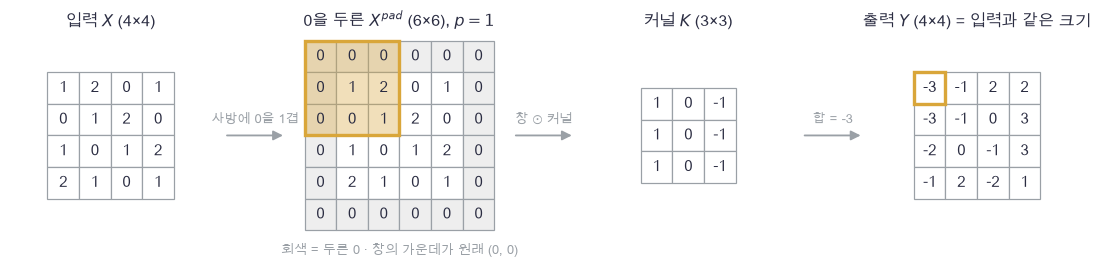

In [9]:
plot_padding_scene(grid_X, grid_Xp, grid_K, grid_Y, (0, 0))

🔍 **확인** · 회색 칸이 두른 0입니다. 금색 창을 (0, 0)에 대면 창의 가운데가 원래 입력의 (0, 0) 위에 놓입니다. 0 없이 댔다면 창의 가운데는 (1, 1)이 첫 자리였고 출력은 2×2였을 것입니다. 창이 놓일 자리가 6 − 3 + 1 = 4개라 출력이 4×4, 입력과 같습니다.
두른 0은 곱해도 0이라 합에 아무것도 보태지 않습니다. 가장자리 출력은 창의 일부만 실제 입력을 보는 셈입니다.

아래는 예시 7을 학습 전 난수 커널 하나씩으로 conv1 → pool → conv2 → pool에 통과시킨 것입니다. 학습 전이라 특성 맵의 무늬에는 뜻이 없고, **크기**만 봅니다.

In [10]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · conv_forward, pool_forward (📎 05 함수 셀)
rng = np.random.default_rng(5)                                        # 이 노트북의 검산·그림용 난수 생성기. 2·4절도 이어 씁니다
flow_K1 = rng.normal(size=(1, 1, 5, 5)) * np.sqrt(2 / 25)            # (1, 1, 5, 5): 학습 전 난수 커널 하나 (He 초기화, 04번 9절)
flow_K2 = rng.normal(size=(1, 1, 5, 5)) * np.sqrt(2 / 25)
flow_Z1 = conv_forward(mnist_7, flow_K1, np.zeros(1), 1, 2)[0]       # (1, 1, 28, 28): p = 2라 크기 유지
flow_P1 = pool_forward(np.maximum(flow_Z1, 0), "max")[0]             # (1, 1, 14, 14): ReLU 뒤 최대 풀링
flow_Z2 = conv_forward(flow_P1, flow_K2, np.zeros(1), 1, 0)[0]       # (1, 1, 10, 10): p = 0이라 4 줄어듦
flow_P2 = pool_forward(np.maximum(flow_Z2, 0), "max")[0]             # (1, 1, 5, 5)
flow_maps = [mnist_7[0, 0], flow_Z1[0, 0], flow_P1[0, 0], flow_Z2[0, 0], flow_P2[0, 0]]   # 그림용 2차원 배열 다섯
print("크기 흐름:", [m.shape[0] for m in flow_maps])

크기 흐름: [28, 28, 14, 10, 5]


In [11]:
# 쓰는 것: conv_forward, conv_backward, pool_forward, pool_backward (📎 05 함수 셀)
ones_K = np.ones((1, 1, 5, 5))                                        # 커널을 모두 1로: 창 안의 모든 칸이 기여
rf_Z1, rf_cache1 = conv_forward(np.zeros((1, 1, 28, 28)), ones_K, np.zeros(1), 1, 2)
rf_P1, rf_pcache1 = pool_forward(rf_Z1, "mean")                       # 평균 풀링: 네 칸 모두에 기울기가 돌아감
rf_Z2, rf_cache2 = conv_forward(rf_P1, ones_K, np.zeros(1), 1, 0)
rf_P2, rf_pcache2 = pool_forward(rf_Z2, "mean")
rf_G = np.zeros_like(rf_P2)                                           # (1, 1, 5, 5)
rf_G[0, 0, 2, 2] = 1.                                                 # 마지막 5×5의 가운데 칸 (2, 2) 하나에서만 기울기 출발
rf_dZ2 = pool_backward(rf_G, rf_pcache2)                              # (1, 1, 10, 10)
rf_dP1 = conv_backward(rf_dZ2, rf_cache2)[0]                          # (1, 1, 14, 14)
rf_dX = conv_backward(pool_backward(rf_dP1, rf_pcache1), rf_cache1)[0]   # (1, 1, 28, 28): 입력까지 돌아온 기울기
rf_rows = np.flatnonzero(rf_dX[0, 0].sum(axis=1))                     # 기울기가 0이 아닌 행 번호
rf_cols = np.flatnonzero(rf_dX[0, 0].sum(axis=0))
rf_box = (rf_rows[0], rf_cols[0], len(rf_rows), len(rf_cols))         # (위, 왼쪽, 높이, 너비): 칸 (2, 2)가 보는 입력 창
print("칸 (2, 2)가 보는 입력 창: 행", rf_rows[0], "–", rf_rows[-1], "· 열", rf_cols[0], "–", rf_cols[-1], "· 한 변", len(rf_rows))

칸 (2, 2)가 보는 입력 창: 행 6 – 21 · 열 6 – 21 · 한 변 16


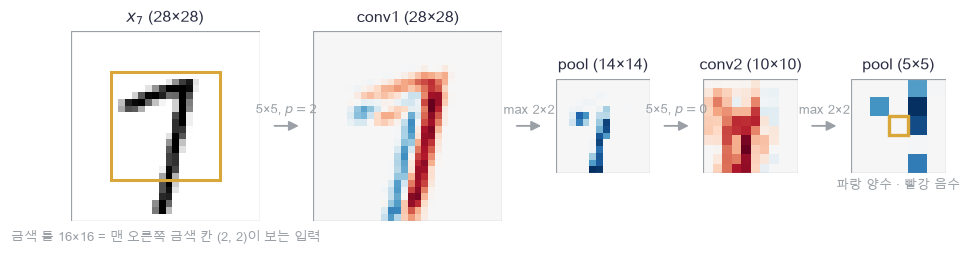

In [12]:
plot_feature_flow(flow_maps, ["$x_7$", "conv1", "pool", "conv2", "pool"],
                  ["5×5, $p=2$", "max 2×2", "5×5, $p=0$", "max 2×2"], rf_box, (2, 2))

🔍 **확인** · 왼쪽에서 오른쪽으로 28 → 28 → 14 → 10 → 5입니다. 첫 conv는 padding 2 덕분에 28을 지키고, 두 번째 conv는 padding이 없어 14가 10이 됩니다. 풀링은 절반씩 줄입니다.
맨 오른쪽 5×5의 금색 칸 (2, 2)는 왼쪽 입력의 금색 틀 16×16을 봅니다. 표의 점화식 $16=14+1\cdot2$가 실제 backward로 잰 창과 같습니다. 5×5 창 두 개를 쌓았을 뿐인데 7의 획 대부분이 한 칸 안에 들어옵니다.

아래는 크기 공식과 수용 영역 점화식을 함수로 적고, 위 배열의 실제 모양·backward로 잰 창과 대조합니다. 그다음 파라미터 수를 층마다 셉니다.

In [13]:
def output_size(H, k, stride=1, padding=0):
    """합성곱·풀링 출력의 한 변 (05번 1절 공식): ⌊(H + 2p − k)/s⌋ + 1. H, k, stride, padding: 정수 → 정수."""
    assert H + 2 * padding >= k, "창이 (0을 두른) 입력보다 크면 출력이 없습니다"
    return (H + 2 * padding - k) // stride + 1

In [14]:
def receptive_field(layers):
    """층 목록 [(k, s, p), …]를 차례로 지난 뒤 출력 한 칸이 보는 입력 창의 한 변 r과 누적 stride j.
    점화식 r ← r + (k − 1)·j, j ← j·s (r = 1, j = 1에서 시작). layers: (k, s, p) 튜플의 목록 → (r, j)."""
    r, j = 1, 1
    for k, s, _ in layers:                                # padding은 창의 위치만 옮기고 크기에는 영향이 없습니다
        r = r + (k - 1) * j                               # 이웃 k − 1칸이 입력에서 j픽셀씩
        j = j * s                                         # 다음 층의 한 칸 = 입력 j·s픽셀
    return r, j

In [15]:
# 쓰는 것: flow_maps (1절 흐름 셀) · rf_box (1절 수용 영역 셀)
LENET_LAYERS = [(5, 1, 2), (2, 2, 0), (5, 1, 0), (2, 2, 0)]           # (k, s, p): conv1, pool1, conv2, pool2
size_flow = [28]
for k, s, p in LENET_LAYERS:
    size_flow.append(output_size(size_flow[-1], k, s, p))
assert size_flow == [28, 28, 14, 10, 5], "크기 흐름은 28 → 28 → 14 → 10 → 5여야 합니다"
assert size_flow == [m.shape[0] for m in flow_maps], "공식의 크기가 위 그림의 실제 배열 모양과 같아야 합니다"
assert output_size(28, 5, 1, 2) == 28, "p = 2, k = 5면 크기가 유지되어야 합니다"
assert output_size(32, 5, 1, 0) == 28, "원래 LeNet-5는 32×32 입력에 padding 없이 5×5를 대어 28×28을 얻었습니다"
rf_conv2, _ = receptive_field(LENET_LAYERS[:3])
rf_pool2, jump_pool2 = receptive_field(LENET_LAYERS)
assert (rf_conv2, rf_pool2, jump_pool2) == (14, 16, 4), "손계산: conv2 뒤 14, pool2 뒤 16, 누적 stride 4"
assert rf_pool2 == rf_box[2], "점화식의 수용 영역이 backward로 잰 창의 높이와 같아야 합니다"
assert rf_pool2 == rf_box[3], "점화식의 수용 영역이 backward로 잰 창의 너비와 같아야 합니다"
print("크기 흐름", size_flow, "· 수용 영역 5 → 6 → 14 → 16 · 마지막 칸 하나 옆 = 입력", jump_pool2, "픽셀")

크기 흐름 [28, 28, 14, 10, 5] · 수용 영역 5 → 6 → 14 → 16 · 마지막 칸 하나 옆 = 입력 4 픽셀


In [16]:
n_conv1 = 6 * (1 * 5 * 5) + 6                 # 커널 6개 × (채널 1 × 5 × 5) + 편향 6 = 156
n_conv2 = 16 * (6 * 5 * 5) + 16               # 커널 16개 × (채널 6 × 5 × 5) + 편향 16 = 2,416
n_fc1 = 400 * 120 + 120                       # 펼침 16·5·5 = 400 → 120: 48,120
n_fc2 = 120 * 84 + 84                         # 10,164
n_fc3 = 84 * 10 + 10                          # 850
n_lenet = n_conv1 + n_conv2 + n_fc1 + n_fc2 + n_fc3
assert n_lenet == 61706, "LeNet 파라미터 수는 156 + 2,416 + 48,120 + 10,164 + 850 = 61,706이어야 합니다"
n_fc_alternative = (28 * 28 + 1) * 400        # 같은 400차원을 784 화소 완전 연결 하나로 만들면
print(f"파라미터: conv1 {n_conv1} + conv2 {n_conv2:,} + fc1 {n_fc1:,} + fc2 {n_fc2:,} + fc3 {n_fc3} = {n_lenet:,}")
print(f"conv 두 단 {n_conv1 + n_conv2:,}개가 400차원 표현을 만듭니다. 완전 연결 한 층으로 같은 차원을 만들면 {n_fc_alternative:,}개")

파라미터: conv1 156 + conv2 2,416 + fc1 48,120 + fc2 10,164 + fc3 850 = 61,706
conv 두 단 2,572개가 400차원 표현을 만듭니다. 완전 연결 한 층으로 같은 차원을 만들면 314,000개


🔍 **확인** · 공식으로 센 크기 흐름이 실제 배열 모양과 같고, 점화식의 수용 영역 16이 backward로 잰 창의 한 변과 같습니다. 원래 LeNet-5는 32×32 입력에 padding 없이 5×5를 대었는데, 28×28에 $p=2$를 두르는 것과 같은 28×28 특성 맵이 나옵니다.
파라미터 61,706개 중 conv 두 단은 2,572개(4%)뿐이고 첫 완전 연결층 $W_1$ (400, 120)이 48,120개로 대부분입니다. 그런데도 784 화소를 완전 연결 하나로 400차원으로 보내는 314,000개보다 훨씬 적습니다. 합성곱이 위치를 공유하기 때문입니다(05번 1절).

### ✏️ 연습 1 · 두 단 뒤 출력 크기

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

conv(커널 `k`, padding `p`, stride 1) → 2×2 풀링 → conv(커널 `k`, padding 0) → 2×2 풀링을 지난 뒤의 한 변을 돌려줍니다. 1절 공식을 두 번 적용하는 두 줄, 즉 첫 conv 뒤 한 변 `h1`과 (풀링으로 절반이 된 `h1 // 2`에 padding 0으로 댄) 둘째 conv 뒤 한 변 `h2`를 채우세요. 마지막 풀링은 써 두었습니다. 검사는 LeNet의 28×28·padding 2, padding 0, 원래 LeNet-5의 32×32와 1절의 실제 배열로 합니다.

In [17]:
def exercise_two_stage_size(H, k, p):
    """연습 1: conv(k, padding p) → 2×2 풀링 → conv(k, padding 0) → 2×2 풀링 뒤의 한 변. H, k, p: 정수 → 정수."""
    assert H + 2 * p >= k, "창이 (0을 두른) 입력보다 크면 출력이 없습니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: h1 = 첫 conv 뒤 한 변 (1절 공식, stride 1, padding p); h2 = h1 // 2 에 padding 0·커널 k를 댄 둘째 conv 뒤 한 변
    ### 힌트: (H + 2 * p - k) // 1 + 1 꼴을 두 번. 둘째는 입력이 h1 // 2 이고 p = 0
    raise NotImplementedError
    return h2 // 2

In [18]:
def check_two_stage_size(candidate):
    """LeNet 세 경우의 손계산과 1절 흐름의 실제 배열 모양, output_size를 네 번 이은 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: flow_maps (1절 흐름 셀) · output_size (1절)
    assert candidate(28, 5, 2) == 5, "28×28에 padding 2: 28 → 14 → 10 → 5여야 합니다"
    assert candidate(28, 5, 0) == 4, "padding 없이: 24 → 12 → 8 → 4여야 합니다"
    assert candidate(32, 5, 0) == 5, "원래 LeNet-5의 32×32 입력: 28 → 14 → 10 → 5여야 합니다"
    assert candidate(28, 5, 2) == flow_maps[-1].shape[0], "1절 그림의 마지막 특성 맵 한 변과 같아야 합니다"
    chained = output_size(output_size(output_size(output_size(20, 3, 1, 1), 2, 2), 3), 2, 2)   # 1절 함수를 네 번 이음
    assert candidate(20, 3, 1) == chained, "output_size를 conv·pool·conv·pool 순서로 이은 값과 같아야 합니다"
    print("두 단 뒤 출력 크기: 손계산·1절 배열과 일치합니다.")

run_check(check_two_stage_size, exercise_two_stage_size, hint="h1 = (H + 2 * p - k) // 1 + 1 · h2 = (h1 // 2 - k) // 1 + 1")

☐ exercise_two_stage_size: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: h1 = (H + 2 * p - k) // 1 + 1 · h2 = (h1 // 2 - k) // 1 + 1


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
h1 = (H + 2 * p - k) // 1 + 1
h2 = (h1 // 2 - k) // 1 + 1
```

</details>

## 🔑 2. 다섯 층의 forward와 backward를 조립합니다

**이 절에서 가져갈 것:** 파라미터가 있는 층은 conv 둘과 선형층 셋, 다섯입니다. forward는 05번의 `conv_forward`·`pool_forward`와 03번의 `A @ W + b`를 순서대로 부르고, backward는 **같은 순서를 거꾸로** 밟으며 각 층의 backward를 부릅니다. 새 미분은 하나도 없습니다.

05번 5절의 `cnn_forward`는 conv 하나·선형층 하나였습니다. 여기서는 conv 두 단(각각 ReLU·max pool)과 선형층 세 개(앞 둘에 ReLU)를 잇습니다. 층이 늘어도 하는 일은 같습니다. forward는 캐시를 남기고, backward는 캐시를 꺼내 03번 5절의 "상류 기울기 × 국소 미분"을 층마다 반복합니다.

> **용어**
>
> - **완전 연결층(fully connected, FC)**: 03번의 선형층 $Z = AW + b$. 입력의 모든 원소가 모든 출력에 연결됩니다. 펼친 400차원 뒤에 120 → 84 → 10으로 셋을 둡니다.
> - **He 초기화**(04번 9절): ReLU 앞 가중치의 표준편차를 $\sqrt{2/D_{in}}$으로 두는 것. 커널이면 $D_{in}=C\,k_hk_w$(창 안의 칸 수), 선형층이면 입력 차원입니다. 마지막 층은 ReLU가 없어 $\sqrt{1/84}$.
> - **캐시(cache)**: forward가 backward를 위해 남겨 두는 중간값. 05번 2절의 패치 행렬 $P$, 4절의 최댓값 번호, 03번의 ReLU 앞 값 $Z$가 들어 있습니다.

forward (모양은 $N$장 기준):

$$\begin{aligned}
Z_1&=\mathrm{conv}(X,K_1,c_1;\,p=2) &&(N,6,28,28), & P_1&=\mathrm{maxpool}(\mathrm{ReLU}(Z_1)) &&(N,6,14,14),\\
Z_2&=\mathrm{conv}(P_1,K_2,c_2;\,p=0) &&(N,16,10,10), & P_2&=\mathrm{maxpool}(\mathrm{ReLU}(Z_2)) &&(N,16,5,5),\\
F&=\mathrm{flatten}(P_2) &&(N,400), & Z_3&=FW_1+b_1,\ A_3=\mathrm{ReLU}(Z_3) &&(N,120),\\
Z_4&=A_3W_2+b_2,\ A_4=\mathrm{ReLU}(Z_4) &&(N,84), & \mathrm{logits}&=A_4W_3+b_3 &&(N,10).
\end{aligned}$$

파라미터 모양은 $K_1$ (6, 1, 5, 5), $c_1$ (6,), $K_2$ (16, 6, 5, 5), $c_2$ (16,), $W_1$ (400, 120), $b_1$ (120,), $W_2$ (120, 84), $b_2$ (84,), $W_3$ (84, 10), $b_3$ (10,)입니다. $K_2$의 두 번째 축이 6인 것은 conv2가 conv1의 특성 맵 6장을 **채널**로 받기 때문입니다(05번 1절의 $\sum_c$).

backward는 $G=\partial L/\partial\,\mathrm{logits}$ $(N,10)$에서 출발해 거꾸로 갑니다. 선형층은 03번 5절의 세 식, ReLU는 $\odot\,1[Z>0]$, 펼침은 `reshape`를 되돌리는 것, 풀링·conv는 05번의 backward입니다.

$$dW_3=A_4^\top G,\quad db_3=\sum_n G,\quad dZ_4=(GW_3^\top)\odot1[Z_4>0],\quad\ldots,\quad
dP_2=\mathrm{reshape}(dZ_3W_1^\top)\ (N,16,5,5),\quad dZ_2=\mathrm{poolback}(dP_2)\odot1[Z_2>0],\quad\ldots$$

아래 도식은 이 흐름을 블록으로 그린 것입니다. 금색 상자가 파라미터가 있는 다섯 층이고 상자 아래가 그 단계의 텐서 모양입니다. 그다음 그림은 학습 전 난수 파라미터로 예시 7을 실제로 통과시킨 값입니다. 계산은 05번 함수와 행렬곱만으로 손으로 잇고, 뒤의 `lenet_forward`가 같은 값을 내는지 검산합니다.

> **코드**
>
> - `p = {"K1": …, "c1": …, …}`: 파라미터 열 개를 이름으로 찾는 사전(05번 5절). `grads`도 같은 키로 만듭니다.
> - `for key in ("c1", "c2", "b1", "b2", "b3"): probe_p[key] = …`: 튜플의 이름을 차례로 꺼내 그 키의 값만 바꿉니다.
> - `array.reshape(-1)`: 배열을 한 줄로 편 **보기**. 같은 메모리를 가리켜 여기서 값을 바꾸면 원래 배열도 바뀝니다. `rng.choice(size, 60, replace=False)`: 0…size−1 중 60개를 겹치지 않게 뽑은 번호.
> - `sum(v.size for v in p.values())`: 사전의 배열마다 원소 수를 더한 것 = 파라미터 총수.

In [19]:
lenet_top = [("입력", "(N, 1, 28, 28)"), ("conv1 5×5, 커널 6\n+ ReLU", "(N, 6, 28, 28)"), ("max pool 2×2", "(N, 6, 14, 14)"),
             ("conv2 5×5, 커널 16\n+ ReLU", "(N, 16, 10, 10)"), ("max pool 2×2", "(N, 16, 5, 5)")]       # 윗줄 (이름, 모양). \n은 상자 안 줄바꿈
lenet_bottom = [("펼침", "(N, 400)"), ("FC 400 → 120\n+ ReLU", "(N, 120)"), ("FC 120 → 84\n+ ReLU", "(N, 84)"),
                ("FC 84 → 10", "(N, 10) logit"), ("softmax CE", "손실 1개")]                                # 아랫줄

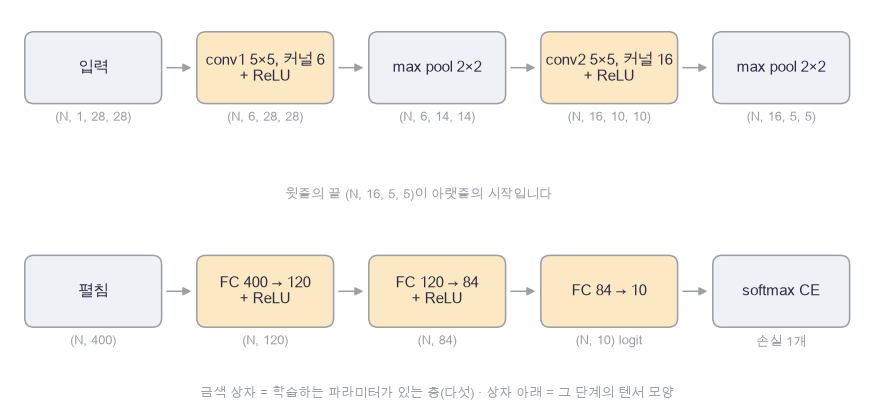

In [20]:
plot_lenet_blocks(lenet_top, lenet_bottom, param_top=(1, 3), param_bottom=(1, 2, 3))

In [21]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · conv_forward, pool_forward (📎 05 함수 셀) · rng (1절 흐름 셀)
trace_K1 = rng.normal(size=(6, 1, 5, 5)) * np.sqrt(2 / 25)          # (6, 1, 5, 5): 학습 전 커널 6개 (He: 창 안의 칸 25)
trace_K2 = rng.normal(size=(16, 6, 5, 5)) * np.sqrt(2 / 150)        # (16, 6, 5, 5): 입력 채널 6 → 창 안의 칸 150
trace_W1 = rng.normal(size=(400, 120)) * np.sqrt(2 / 400)           # (400, 120)
trace_W2 = rng.normal(size=(120, 84)) * np.sqrt(2 / 120)            # (120, 84)
trace_W3 = rng.normal(size=(84, 10)) * np.sqrt(1 / 84)              # (84, 10): 마지막 층은 ReLU가 없음
trace_Z1 = conv_forward(mnist_7, trace_K1, np.zeros(6), 1, 2)[0]     # (1, 6, 28, 28)
trace_P1 = pool_forward(np.maximum(trace_Z1, 0), "max")[0]           # (1, 6, 14, 14)
trace_Z2 = conv_forward(trace_P1, trace_K2, np.zeros(16), 1, 0)[0]   # (1, 16, 10, 10)
trace_P2 = pool_forward(np.maximum(trace_Z2, 0), "max")[0]           # (1, 16, 5, 5)
trace_F = trace_P2.reshape(1, -1)                                    # (1, 400): 펼침
trace_A3 = np.maximum(trace_F @ trace_W1, 0)                         # (1, 120): 편향은 모두 0
trace_A4 = np.maximum(trace_A3 @ trace_W2, 0)                        # (1, 84)
trace_logits = trace_A4 @ trace_W3                                   # (1, 10)
print("7의 흐름:", trace_Z1.shape, "→", trace_P1.shape, "→", trace_Z2.shape, "→", trace_P2.shape,
      "→", trace_F.shape, "→", trace_A3.shape, "→", trace_A4.shape, "→", trace_logits.shape)
print("학습 전 logit:", trace_logits[0], "· 가장 큰 자리", trace_logits.argmax())

7의 흐름: (1, 6, 28, 28) → (1, 6, 14, 14) → (1, 16, 10, 10) → (1, 16, 5, 5) → (1, 400) → (1, 120) → (1, 84) → (1, 10)
학습 전 logit: [-0.7345 -0.7448 -0.4124 -0.7322  0.0185 -0.7181  1.1275 -0.0424 -0.4155
 -0.2518] · 가장 큰 자리 6


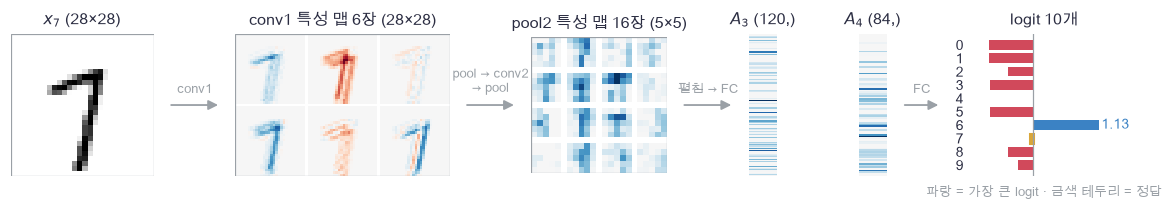

In [22]:
plot_lenet_trace(mnist_7[0, 0], trace_Z1[0], trace_P2[0], trace_A3[0], trace_A4[0], trace_logits[0], 7)

🔍 **확인** · 도식의 윗줄이 conv 두 단, 아랫줄이 펼침과 완전 연결 세 층입니다. 파라미터가 있는 금색 상자는 다섯 개뿐이고 풀링·펼침은 모양만 바꿉니다.
위 그림에서 7 한 장이 conv1 특성 맵 6장(28×28), pool2 특성 맵 16장(5×5), 은닉 120·84, logit 10개로 바뀝니다. 학습 전이라 logit은 뜻이 없고 정답 7(금색 테두리)이 가장 크지도 않습니다. 3절에서 학습한 뒤 같은 7의 특성 맵과 예측을 다시 봅니다.

아래 세 셀이 이 노트북의 모델입니다: 초기화 → forward → backward. 그다음 검산에서 (1) 위에서 손으로 이은 값과 `lenet_forward`가 같은지, (2) 열 개 파라미터와 입력의 기울기가 중심차분과 맞는지 봅니다.

📎 05번 5절처럼 검사 입력은 난수를 씁니다. 실제 이미지는 빈 종이 부분이 정확히 0이라 $Z_1=c_1=0$이 되어 ReLU의 꺾임과 max pool의 동률에 걸리고, 그 자리의 미분은 정의되지 않습니다. 같은 이유로 검사용 편향도 난수로 둡니다. 원소가 48,000·10,080개인 $W_1$·$W_2$는 60자리씩 뽑아 중심차분을 재고, 나머지 여덟 파라미터(3,626개)와 입력(1,568개)은 전부 잽니다.

In [23]:
def init_lenet(seed=503):
    """LeNet 파라미터 사전 (He 초기화, 04번 9절): 커널은 표준편차 √(2/(C·k·k)), 선형층은 √(2/D_in), 마지막 층은 √(1/84), 편향은 0.
    seed: 정수 → {"K1": (6, 1, 5, 5), "c1": (6,), "K2": (16, 6, 5, 5), "c2": (16,), "W1": (400, 120), "b1": (120,), "W2": (120, 84), "b2": (84,), "W3": (84, 10), "b3": (10,)}."""
    rng_init = np.random.default_rng(seed)
    return {"K1": rng_init.normal(size=(6, 1, 5, 5)) * np.sqrt(2 / 25), "c1": np.zeros(6),
            "K2": rng_init.normal(size=(16, 6, 5, 5)) * np.sqrt(2 / 150), "c2": np.zeros(16),
            "W1": rng_init.normal(size=(400, 120)) * np.sqrt(2 / 400), "b1": np.zeros(120),
            "W2": rng_init.normal(size=(120, 84)) * np.sqrt(2 / 120), "b2": np.zeros(84),
            "W3": rng_init.normal(size=(84, 10)) * np.sqrt(1 / 84), "b3": np.zeros(10)}

In [24]:
def lenet_forward(X, p):
    """LeNet forward: conv1(p=2) → ReLU → max pool → conv2 → ReLU → max pool → 펼침 → FC 120 → ReLU → FC 84 → ReLU → FC 10.
    X: (N, 1, 28, 28), p: 파라미터 사전 → (logits: (N, 10), cache: backward용 중간값 튜플)."""
    # 쓰는 것: conv_forward, pool_forward (📎 05 함수 셀)
    Z1, conv1_cache = conv_forward(X, p["K1"], p["c1"], 1, 2)       # (N, 6, 28, 28): padding 2로 크기 유지
    P1, pool1_cache = pool_forward(np.maximum(Z1, 0), "max")        # (N, 6, 14, 14)
    Z2, conv2_cache = conv_forward(P1, p["K2"], p["c2"], 1, 0)      # (N, 16, 10, 10)
    P2, pool2_cache = pool_forward(np.maximum(Z2, 0), "max")        # (N, 16, 5, 5)
    F = P2.reshape(len(X), -1)                                      # (N, 400): 펼침
    Z3 = F @ p["W1"] + p["b1"]                                      # (N, 120)
    A3 = np.maximum(Z3, 0)
    Z4 = A3 @ p["W2"] + p["b2"]                                     # (N, 84)
    A4 = np.maximum(Z4, 0)
    logits = A4 @ p["W3"] + p["b3"]                                 # (N, 10)
    cache = (Z1, conv1_cache, pool1_cache, Z2, conv2_cache, pool2_cache, P2.shape, F, Z3, A3, Z4, A4)
    return logits, cache

In [25]:
def lenet_backward(dlogits, cache, p):
    """LeNet backward: forward를 거꾸로. 선형층 세 식(03번 5절) → ReLU 도함수 → 펼침 되돌리기 → pool backward → conv backward (05번).
    dlogits: (N, 10), cache: lenet_forward의 것, p: 파라미터 사전 → (dX: (N, 1, 28, 28), grads: p와 같은 키의 사전)."""
    # 쓰는 것: conv_backward, pool_backward (📎 05 함수 셀)
    Z1, conv1_cache, pool1_cache, Z2, conv2_cache, pool2_cache, P2_shape, F, Z3, A3, Z4, A4 = cache
    grads = {}
    grads["W3"], grads["b3"] = A4.T @ dlogits, dlogits.sum(axis=0)       # 1. FC3: dW = Aᵀ G, db = Σ_n G
    dZ4 = (dlogits @ p["W3"].T) * (Z4 > 0)                               # (N, 84): dA = G Wᵀ 뒤 ReLU 도함수
    grads["W2"], grads["b2"] = A3.T @ dZ4, dZ4.sum(axis=0)               # 2. FC2
    dZ3 = (dZ4 @ p["W2"].T) * (Z3 > 0)                                   # (N, 120)
    grads["W1"], grads["b1"] = F.T @ dZ3, dZ3.sum(axis=0)                # 3. FC1
    dP2 = (dZ3 @ p["W1"].T).reshape(P2_shape)                            # (N, 16, 5, 5): 펼침을 되돌림
    dZ2 = pool_backward(dP2, pool2_cache) * (Z2 > 0)                     # 4. pool2 → ReLU: (N, 16, 10, 10)
    dP1, grads["K2"], grads["c2"] = conv_backward(dZ2, conv2_cache)      # 5. conv2: dP1 (N, 6, 14, 14)
    dZ1 = pool_backward(dP1, pool1_cache) * (Z1 > 0)                     # 6. pool1 → ReLU: (N, 6, 28, 28)
    dX, grads["K1"], grads["c1"] = conv_backward(dZ1, conv1_cache)       # 7. conv1
    return dX, grads

In [26]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · rng (1절 흐름 셀) · n_lenet (1절 파라미터 셀) · trace_K1, trace_K2, trace_W1, trace_W2, trace_W3, trace_logits (2절 흐름 셀)
trace_p = {"K1": trace_K1, "c1": np.zeros(6), "K2": trace_K2, "c2": np.zeros(16), "W1": trace_W1, "b1": np.zeros(120),
           "W2": trace_W2, "b2": np.zeros(84), "W3": trace_W3, "b3": np.zeros(10)}
np.testing.assert_allclose(lenet_forward(mnist_7, trace_p)[0], trace_logits)   # 검산: 손으로 이은 forward = lenet_forward
probe_p = init_lenet(504)
for key in ("c1", "c2", "b1", "b2", "b3"):
    probe_p[key] = rng.normal(size=probe_p[key].shape) * 0.1        # 편향도 난수로: Z가 정확히 0인 자리(ReLU 꺾임·max pool 동률)를 피함
probe_X = rng.normal(size=(2, 1, 28, 28))                            # (2, 1, 28, 28): 검사 입력도 난수 (05번 5절과 같은 이유)
probe_logits, probe_cache = lenet_forward(probe_X, probe_p)
probe_G = rng.normal(size=probe_logits.shape)                        # (2, 10): 임의의 상류 기울기
probe_dX, probe_grads = lenet_backward(probe_G, probe_cache, probe_p)
for key, value in probe_p.items():
    assert probe_grads[key].shape == value.shape, f"{key}의 기울기 모양은 {value.shape}이어야 합니다"
assert sum(v.size for v in probe_p.values()) == n_lenet, "init_lenet의 원소 수는 1절에서 센 61,706이어야 합니다"
print("손으로 이은 forward = lenet_forward · 기울기 모양 열 개 모두 파라미터와 같음 · 파라미터", sum(v.size for v in probe_p.values()))

손으로 이은 forward = lenet_forward · 기울기 모양 열 개 모두 파라미터와 같음 · 파라미터 61706


In [27]:
def probe_scalar():
    """검사기용: 스칼라 L = Σ logits ⊙ G. 인자 없이 2절 검산 셀의 probe_X, probe_p, probe_G를 씁니다."""
    return float(np.sum(lenet_forward(probe_X, probe_p)[0] * probe_G))


lenet_errors = {}
for key in ("K1", "c1", "K2", "c2", "b1", "b2", "W3", "b3"):          # 원소 3,626개: 전부 중심차분
    lenet_errors[key] = rel_error(probe_grads[key], numerical_gradient(probe_scalar, probe_p[key]))
lenet_errors["X"] = rel_error(probe_dX, numerical_gradient(probe_scalar, probe_X))   # 입력 미분 1,568개도 전부
print({key: f"{value:.1e}" for key, value in lenet_errors.items()})

{'K1': '2.6e-09', 'c1': '1.9e-09', 'K2': '1.9e-09', 'c2': '3.4e-09', 'b1': '4.4e-09', 'b2': '2.3e-09', 'W3': '7.3e-11', 'b3': '6.0e-10', 'X': '1.4e-08'}


In [28]:
def sampled_gradient(scalar, array, idx, eps=1e-6):
    """큰 배열의 뽑은 자리 idx에서만 중심차분 (L(x+ε) − L(x−ε))/2ε (01번 3절). array를 제자리에서 흔들었다가 되돌립니다.
    scalar: 인자 없는 함수, array: 배열, idx: 펼친 번호 (M,) → (M,)."""
    flat = array.reshape(-1)                                          # 같은 메모리를 보는 1차원 보기
    numeric = np.zeros(len(idx))
    for n, i in enumerate(idx):
        original = flat[i]
        flat[i] = original + eps
        plus = scalar()
        flat[i] = original - eps
        minus = scalar()
        flat[i] = original                                            # 원상복구
        numeric[n] = (plus - minus) / (2 * eps)
    return numeric

In [29]:
# 쓰는 것: rng (1절 흐름 셀) · probe_p, probe_grads, probe_G, probe_cache (2절 검산 셀)
for key in ("W1", "W2"):                                              # 원소 48,000·10,080개: 60자리씩 뽑아 검사
    sample_idx = rng.choice(probe_p[key].size, 60, replace=False)
    numeric = sampled_gradient(probe_scalar, probe_p[key], sample_idx)
    lenet_errors[key] = rel_error(probe_grads[key].reshape(-1)[sample_idx], numeric)
assert max(lenet_errors.values()) < 1e-6, "열 개 파라미터와 입력의 상대오차가 모두 1e−6 아래여야 합니다"
np.testing.assert_allclose(probe_grads["b3"], probe_G.sum(axis=0))              # 검산: 손계산. db₃ = 상류 기울기를 표본 축으로 더한 것
np.testing.assert_allclose(probe_grads["W3"], probe_cache[-1].T @ probe_G)      # 검산: 손계산. dW₃ = A₄ᵀ G (캐시의 마지막 원소가 A₄)
print("LeNet 전체 미분 최대 상대오차:", f"{max(lenet_errors.values()):.2e}", "· 마지막 층 편향·가중치의 손계산 일치")

LeNet 전체 미분 최대 상대오차: 1.43e-08 · 마지막 층 편향·가중치의 손계산 일치


🔍 **확인** · 열 개 파라미터와 입력 모두 중심차분과의 상대오차가 $10^{-8}$ 수준입니다. conv 두 단·풀링 두 번·선형층 셋을 이어도 각 층의 backward를 거꾸로 부르기만 하면 됩니다. 마지막 층의 $db_3=\sum_n G$, $dW_3=A_4^\top G$는 캐시로 손계산해도 같습니다.
05번의 conv·pool backward가 이미 검산되어 있으므로, 여기서 새로 확인한 것은 **잇는 순서**와 펼침의 `reshape`가 맞는지뿐입니다.

### ✏️ 연습 2 · 펼침 되돌리기와 첫 선형층의 backward

펼침 뒤 첫 선형층 $Z_3 = FW_1 + b_1$의 backward에서 상류 기울기 `dZ3` `(N, 120)`으로 $dW_1=F^\top dZ_3$ `(400, 120)`과, $dZ_3W_1^\top$ `(N, 400)`을 풀링 출력 모양 `P2_shape` `(N, 16, 5, 5)`로 되돌린 `dP2` 두 줄을 채우세요. 검사는 손계산 하나와 같은 식을 반복문으로 쓴 값으로 합니다.

In [30]:
def exercise_unflatten_backward(dZ3, F, W1, P2_shape):
    """연습 2: 펼침 뒤 첫 선형층의 backward. dZ3: (N, D_out), F: (N, D_in), W1: (D_in, D_out), P2_shape: 풀링 출력 모양 → (dW1: (D_in, D_out), dP2: P2_shape)."""
    assert dZ3.shape[1] == W1.shape[1], "dZ3의 열 수는 W1의 열 수(출력 차원)여야 합니다"
    assert F.shape[1] == W1.shape[0], "F의 열 수는 W1의 행 수(펼친 차원)여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dW1 = Fᵀ dZ3 (모양 (D_in, D_out)); dP2 = dZ3 W1ᵀ 를 P2_shape로 접은 것
    ### 힌트: 2절 lenet_backward의 grads["W1"]과 dP2 두 줄. 접기는 .reshape(P2_shape)
    raise NotImplementedError
    return dW1, dP2

In [31]:
def check_unflatten_backward(candidate):
    """(1, 4) 손계산 하나와, 같은 식을 반복문으로 쓴 값(난수 입력)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    example_dZ3 = np.array([[1., -1.]])                                 # (1, 2): 표본 1개, 출력 2
    example_F = np.array([[1., 2., 0., 1.]])                            # (1, 4): 펼친 입력
    example_W1 = np.array([[1., 0.], [0., 1.], [1., 1.], [2., 0.]])     # (4, 2)
    dW1, dP2 = candidate(example_dZ3, example_F, example_W1, (1, 1, 2, 2))
    assert np.shape(dW1) == (4, 2), f"dW1은 W1과 같은 (4, 2)여야 하는데 {np.shape(dW1)}입니다"
    assert np.shape(dP2) == (1, 1, 2, 2), f"dP2는 P2_shape (1, 1, 2, 2)여야 하는데 {np.shape(dP2)}입니다"
    np.testing.assert_allclose(dW1, [[1., -1.], [2., -2.], [0., 0.], [1., -1.]])   # 검산: Fᵀ dZ3. 행 d는 F[0, d]·[1, −1]
    np.testing.assert_allclose(dP2, [[[[1., -1.], [0., 2.]]]])                    # 검산: dZ3 W1ᵀ = [1·1−1·0, 1·0−1·1, 1·1−1·1, 1·2−1·0]을 (2, 2)로 접음
    rng_check = np.random.default_rng(58)
    dZ3_c, F_c, W1_c = rng_check.normal(size=(3, 5)), rng_check.normal(size=(3, 8)), rng_check.normal(size=(8, 5))
    dW1_c, dP2_c = candidate(dZ3_c, F_c, W1_c, (3, 2, 2, 2))
    dW1_loop = np.zeros((8, 5))
    for n in range(3):
        for d in range(8):
            for k in range(5):
                dW1_loop[d, k] += F_c[n, d] * dZ3_c[n, k]              # 표본마다 F[n, d]·dZ3[n, k]를 더함
    np.testing.assert_allclose(dW1_c, dW1_loop)                        # 검산: 반복문으로 쓴 Fᵀ dZ3
    np.testing.assert_allclose(dP2_c.reshape(3, 8), dZ3_c @ W1_c.T)    # 검산: 접기 전 (3, 8)은 dZ3 W1ᵀ
    print("펼침 되돌리기와 선형층 backward: 손계산·반복문과 일치합니다.")

run_check(check_unflatten_backward, exercise_unflatten_backward, hint="dW1 = F.T @ dZ3 · dP2 = (dZ3 @ W1.T).reshape(P2_shape)")

☐ exercise_unflatten_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW1 = F.T @ dZ3 · dP2 = (dZ3 @ W1.T).reshape(P2_shape)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW1 = F.T @ dZ3
dP2 = (dZ3 @ W1.T).reshape(P2_shape)
```

</details>

## 🔑 3. 실제 데이터 학습 루프: 미니배치·에폭·검증

**이 절에서 가져갈 것:** 01b번의 루프(에폭마다 섞어 $B$개씩 끊기)에 04번의 Adam을 붙이고, 에폭이 끝날 때마다 검증 정확도를 기록합니다. 한 에폭은 $\lceil N/B\rceil$ 스텝이고, test 집합은 학습 중 한 번도 보지 않다가 5절에서 한 번만 봅니다.

05번은 500장에서 스텝마다 50장을 뽑았습니다. 20,000장이면 01b번처럼 **에폭** 단위로 순회합니다. 에폭마다 순서를 섞어 64장씩 끊으면 $\lceil 20000/64\rceil=313$스텝이고 마지막 배치는 $20000-64\cdot312=32$장입니다. 스텝마다 forward → CE → backward → Adam을 돌리고, 에폭 끝에 갱신에 쓰지 않은 검증 2,000장의 정확도를 잽니다.

> **용어**
>
> - **에폭(epoch)**: 학습 집합 전체를 한 번씩 다 쓰는 단위(01b번 3절). 3에폭이면 모든 이미지를 세 번 봅니다.
> - **정확도(accuracy)**: 예측(logit이 가장 큰 숫자)이 정답과 같은 비율. 코드에서는 `np.mean(logits.argmax(axis=1) == y)`.
> - **Adam**(04번 6절): 기울기의 1차·2차 이동평균으로 파라미터마다 보폭을 맞추는 optimizer. 편향 보정 뒤 $m/(\sqrt v+\epsilon)$ 방향으로 학습률 0.002만큼 갑니다.

$$\text{한 에폭의 스텝 수}=\left\lceil\frac{N}{B}\right\rceil,\qquad
J=-\frac1B\sum_{n\in\mathrm{batch}}\log\frac{e^{z_{n,y_n}}}{\sum_k e^{z_{n,k}}},\qquad
\frac{\partial J}{\partial z_{n,k}}=\frac{P_{n,k}-1[k=y_n]}{B}.$$

$J$는 02번 8절의 softmax CE(배치 평균)이고, 그 기울기 $(P-T)/B$가 `lenet_backward`의 첫 입력 `dlogits`입니다. $z$는 logit $(B, 10)$, $P$는 softmax 확률, $T$는 정답 자리만 1인 one-hot입니다.

아래 그림은 데이터를 어떻게 나누고 자르는지입니다. 6만 장 중 앞 20,000장이 학습, 뒤 2,000장이 검증, test 10,000장은 따로 둡니다. 가운데 38,000장은 성능에 해로워서 버린 것이 아니라 이 노트북의 실행 시간을 1분 안에 두려고 쓰지 않은 것입니다(20,000장·3에폭에서 학습 루프가 약 22초). 장수를 늘리면 정확도는 조금 더 오릅니다. 가운데는 첫 에폭을 64장씩 끊은 313스텝, 오른쪽은 첫 배치 64장입니다.

> **코드**
>
> - `rng.permutation(size)` · `order[start:start + B]` · `range(0, size, B)`: 01b번 3절의 `epoch_batches` 그대로. 섞은 번호를 앞에서부터 B개씩 자릅니다.
> - `X[idx]`: 정수 배열 `idx` `(64,)`로 고른 64장 `(64, 1, 28, 28)`.
> - `for start in range(0, len(X), chunk)`: 검증·test 수천 장은 한 번에 넣으면 패치 행렬이 수백 MB라 500장씩 끊어 forward만 합니다.
> - `{key: (np.zeros_like(v), np.zeros_like(v)) for key, v in p.items()}`: Adam 상태 (m, v)를 파라미터마다 0으로 (05번 5절).

In [32]:
# 쓰는 것: mnist_X_train, mnist_y_train (📎 데이터 셀)
N_TRAIN, BATCH = len(mnist_X_train), 64
steps_per_epoch = math.ceil(N_TRAIN / BATCH)                           # ⌈20000/64⌉ = 313
last_batch = N_TRAIN - BATCH * (steps_per_epoch - 1)                   # 20000 − 64·312 = 32
assert (steps_per_epoch, last_batch) == (313, 32), "손계산: 313스텝, 마지막 배치 32장"
rng_plan = np.random.default_rng(1)
plan_order = rng_plan.permutation(N_TRAIN)                            # (20000,): 첫 에폭의 순서
plan_batch = plan_order[:BATCH]                                        # (64,): 첫 배치의 번호
plan_counts = {"학습 20,000": 20000, "안 씀 38,000": 38000, "검증 2,000": 2000}   # 60,000장 파일의 실제 순서
print("에폭당 스텝", steps_per_epoch, "· 마지막 배치", last_batch, "장 · 첫 배치의 번호", plan_batch[:6], "… · 정답", mnist_y_train[plan_batch[:6]])

에폭당 스텝 313 · 마지막 배치 32 장 · 첫 배치의 번호 [ 3815 18089 15784  7825  7019  3298] … · 정답 [3 8 4 8 4 7]


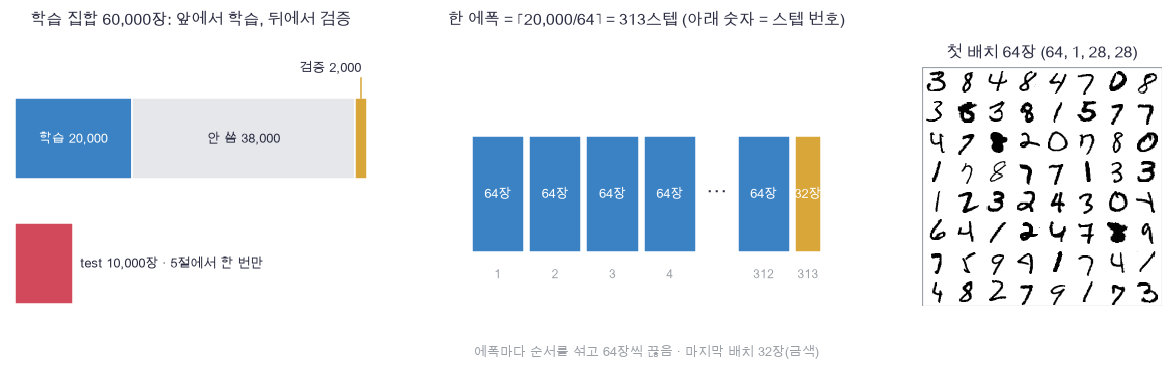

In [33]:
plot_data_plan(plan_counts, 10000, N_TRAIN, steps_per_epoch, BATCH, last_batch, mnist_X_train[plan_batch, 0])

🔍 **확인** · 왼쪽 띠의 파랑 20,000장만 가중치 갱신에 쓰고, 금색 2,000장은 에폭 끝에 정확도만 잽니다. 빨강 test는 이 절에서 아예 건드리지 않습니다. 가운데 마지막 스텝은 32장(금색)으로, 01b번 3절처럼 그 배치도 실제 크기 32로 평균냅니다.
오른쪽 64장은 섞인 순서라 숫자가 뒤섞여 있습니다. 같은 숫자끼리 몰려 있으면 배치 기울기가 한쪽으로 치우칩니다.

아래 다섯 셀은 01b·02·04번의 함수를 이 노트북에 맞게 다시 적은 것이고, 그다음 `train_lenet`이 학습 루프입니다.

In [34]:
def epoch_batches(size, batch_size, rng_epoch):
    """한 에폭의 배치 인덱스 목록 (01b번 3절): 0…size−1을 섞은 뒤 앞에서부터 batch_size개씩 끊습니다.
    size, batch_size: 정수, rng_epoch: 난수 생성기 → ⌈size/batch_size⌉개의 (B,) 정수 배열 목록. 마지막 것만 짧을 수 있습니다."""
    order = rng_epoch.permutation(size)                            # (size,): 표본 번호를 무작위 순서로
    return [order[start:start + batch_size]                        # start부터 batch_size개 자르기
            for start in range(0, size, batch_size)]               # start = 0, B, 2B, …

In [35]:
def ce_loss(logits, y):
    """softmax cross-entropy 평균과 logit 기울기 (02번 8절): J = −mean log P[n, y_n], dZ = (P − T)/N.
    logits: (N, 10), y: (N,) 정수 → (J: 숫자, dZ: (N, 10))."""
    shifted = logits - logits.max(axis=1, keepdims=True)                 # 행마다 최댓값을 빼 지수가 넘치지 않게
    logp = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))  # (N, 10): log softmax
    loss = -logp[np.arange(len(y)), y].mean()                            # 정답 자리의 −log를 평균
    dlogits = np.exp(logp)                                               # (N, 10): P
    dlogits[np.arange(len(y)), y] -= 1                                   # 정답 자리만 1을 빼면 P − T
    return loss, dlogits / len(y)

In [36]:
def adam_update(p, grads, state, step, lr=0.002):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수, lr: 학습률."""
    for key in p:                                                     # "K1", "c1", …, "b3" 차례로
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [37]:
def predict_logits(X, p, chunk=500):
    """수천 장을 chunk장씩 끊어 forward만 (캐시는 버림). X: (N, 1, 28, 28), p: 파라미터 사전 → logits: (N, 10)."""
    # 쓰는 것: lenet_forward (2절)
    pieces = [lenet_forward(X[start:start + chunk], p)[0]             # (chunk, 10)씩
              for start in range(0, len(X), chunk)]
    return np.concatenate(pieces)                                     # 세로로 이어 붙여 (N, 10)


def accuracy(logits, y):
    """정확도: logit이 가장 큰 숫자가 정답과 같은 비율. logits: (N, 10), y: (N,) → 숫자."""
    return float(np.mean(logits.argmax(axis=1) == y))

In [38]:
def train_lenet(p, X, y, X_valid, y_valid, epochs=2, batch_size=64, lr=0.002, seed=505):
    """미니배치 Adam 학습 (01b번 4절의 루프 + 04번 6절의 Adam). 스텝마다 forward → CE → backward → Adam, 에폭 끝마다 검증 정확도.
    p: 파라미터 사전(제자리에서 갱신), X: (N, 1, 28, 28), y: (N,), X_valid·y_valid: 검증 집합 → history: {"loss": 스텝별 배치 CE, "valid_acc": 에폭별, "epoch_steps": 에폭이 끝난 스텝}."""
    # 쓰는 것: epoch_batches, ce_loss, adam_update, predict_logits, accuracy (3절) · lenet_forward, lenet_backward (2절)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed)
    history = {"loss": [], "valid_acc": [], "epoch_steps": []}
    step = 0
    for epoch in range(epochs):
        for idx in epoch_batches(len(X), batch_size, rng_train):      # 1. 이번 배치의 번호 (B,)
            logits, cache = lenet_forward(X[idx], p)                  # 2. forward
            loss, dlogits = ce_loss(logits, y[idx])                   # 3. 손실과 logit 기울기 (P − T)/B
            _, grads = lenet_backward(dlogits, cache, p)              # 4. backward
            step += 1
            adam_update(p, grads, state, step, lr)                    # 5. 갱신 (step은 1부터)
            history["loss"].append(loss)
        history["epoch_steps"].append(step)
        history["valid_acc"].append(accuracy(predict_logits(X_valid, p), y_valid))   # 6. 에폭 끝: 검증 정확도
        print(f"에폭 {epoch + 1}: 스텝 {step} · 마지막 배치 CE {loss:.3f} · 검증 정확도 {history['valid_acc'][-1]:.4f}")
    return history

In [39]:
# 쓰는 것: mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid (📎 데이터 셀) · init_lenet (2절) · steps_per_epoch (3절 계획 셀)
lenet_p = init_lenet(503)
K1_before = lenet_p["K1"].copy()                                      # (6, 1, 5, 5): 학습 전 커널 (그림용 복사본)
t_start = time.perf_counter()
lenet_history = train_lenet(lenet_p, mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid, epochs=3)
train_seconds = time.perf_counter() - t_start
assert len(lenet_history["loss"]) == 3 * steps_per_epoch, "3에폭이면 스텝 수는 3 × 313이어야 합니다"
assert lenet_history["valid_acc"][-1] > 0.95, "학습용 규모에서도 검증 정확도가 95%는 넘어야 합니다"
print(f"학습 {train_seconds:.1f}초 · 검증 정확도 {lenet_history['valid_acc'][-1]:.4f} (n=2000)")
print("이 숫자는 학습용 작은 규모(20,000장·3에폭)의 성능입니다. 벤치마크 수치로 읽지 마세요.")

에폭 1: 스텝 313 · 마지막 배치 CE 0.382 · 검증 정확도 0.9750


에폭 2: 스텝 626 · 마지막 배치 CE 0.055 · 검증 정확도 0.9750


에폭 3: 스텝 939 · 마지막 배치 CE 0.021 · 검증 정확도 0.9825
학습 21.0초 · 검증 정확도 0.9825 (n=2000)
이 숫자는 학습용 작은 규모(20,000장·3에폭)의 성능입니다. 벤치마크 수치로 읽지 마세요.


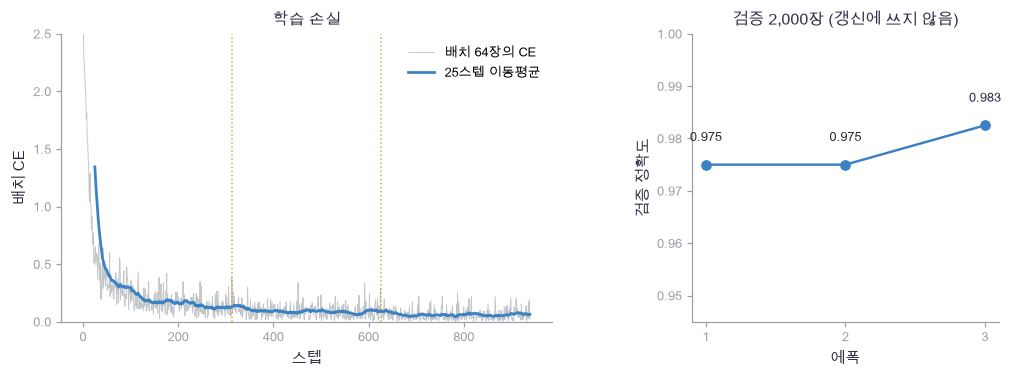

In [40]:
plot_training_result(lenet_history["loss"], 25, lenet_history["epoch_steps"], lenet_history["valid_acc"])

In [41]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · conv_forward (📎 05 함수 셀) · lenet_p, K1_before (3절 학습 셀)
trained_Z1 = conv_forward(mnist_7, lenet_p["K1"], lenet_p["c1"], 1, 2)[0]   # (1, 6, 28, 28): 학습된 conv1이 본 7
K1_delta = lenet_p["K1"] - K1_before                                 # (6, 1, 5, 5): 학습이 커널에 더한 변화 (03번 7절의 W₁ − W₁⁽⁰⁾처럼)
print(f"학습된 conv1 특성 맵 {trained_Z1.shape} · 커널 |값| 최대: 학습 전 {np.abs(K1_before).max():.2f}, 학습 뒤 {np.abs(lenet_p['K1']).max():.2f}, 변화 {np.abs(K1_delta).max():.2f}")

학습된 conv1 특성 맵 (1, 6, 28, 28) · 커널 |값| 최대: 학습 전 1.02, 학습 뒤 1.12, 변화 0.37


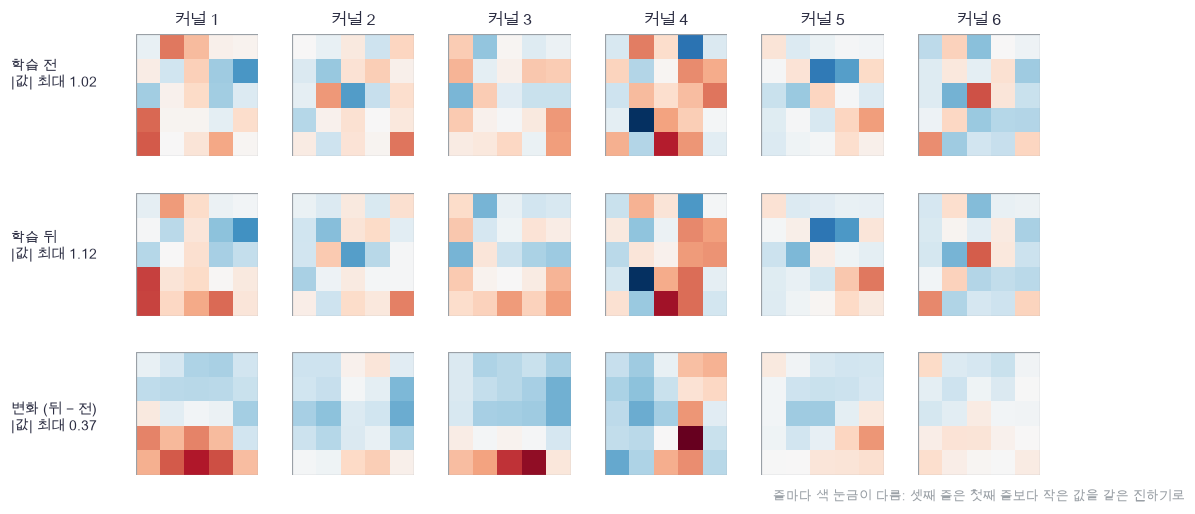

In [42]:
plot_kernels_before_after(K1_before[:, 0], lenet_p["K1"][:, 0], K1_delta[:, 0])

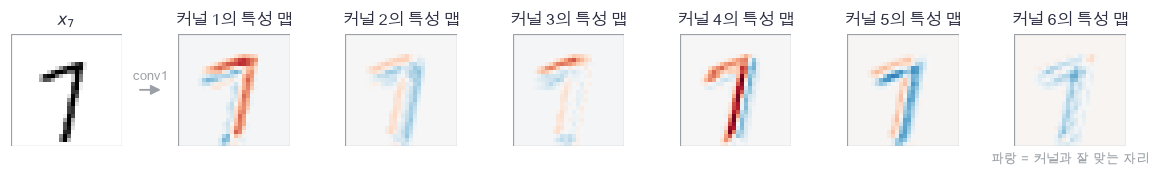

In [43]:
plot_feature_maps(mnist_7[0, 0], trained_Z1[0], 7)

🔍 **확인** · 배치 CE는 스텝마다 흔들리지만 이동평균은 첫 에폭 안에 크게 내려갑니다. 검증 정확도는 첫 에폭 끝에 이미 97% 근처이고 그 뒤 에폭에서는 조금씩만 움직입니다. 검증 집합은 갱신에 쓰지 않았으므로 이 정확도는 "새 손글씨"에 대한 성능입니다.
커널은 학습 전과 뒤가 얼핏 같아 보입니다. He 초기화의 난수 값(±1 정도)에 비해 학습이 더한 변화(셋째 줄)는 작기 때문입니다. 작은 학습 규모에서는 첫 층이 조금만 바뀌어도 뒤 층이 그 출력에 맞춰지므로, 05번 1절처럼 깔끔한 경계 커널이 저절로 생기지는 않습니다. 셋째 줄의 변화가 어느 자리에 몰려 있는지, 그리고 위 특성 맵에서 커널마다 7의 획 가장자리가 다른 방향으로(파랑·빨강이 획의 양쪽에) 나타나는지를 보세요.

### ✏️ 연습 3 · 섞인 순서를 배치로 자르기

01b번의 `epoch_batches`는 섞기와 자르기를 함께 했습니다. 여기서는 이미 섞인 순서 `order` `(size,)`를 받아 앞에서부터 `batch_size`개씩 잘라 목록으로 돌려주는 한 줄을 채우세요. 마지막 배치는 남은 만큼만 들어갑니다. 검사는 표본 10개를 4개씩(손계산 [4, 4, 2])과 20,000개를 64개씩(313스텝, 마지막 32장)으로 합니다.

In [44]:
def exercise_batch_slices(order, batch_size):
    """연습 3: 섞인 번호 order를 앞에서부터 batch_size개씩 자른 목록. order: (size,) 정수 배열, batch_size: 정수 → (B,) 배열의 목록 (마지막만 짧을 수 있음)."""
    assert batch_size >= 1, "batch_size는 1 이상이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: batches = order[start:start + batch_size]를 start = 0, batch_size, 2·batch_size, … 마다 모은 목록
    ### 힌트: 3절 epoch_batches의 return 줄. range(0, len(order), batch_size)
    raise NotImplementedError
    return batches

In [45]:
def check_batch_slices(candidate):
    """표본 10개를 4개씩, 20,000개를 64개씩 자른 결과를 손계산·3절 epoch_batches와 비교합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: epoch_batches, steps_per_epoch, last_batch (3절)
    batches = candidate(np.arange(10), 4)
    assert [len(b) for b in batches] == [4, 4, 2], "10개를 4개씩 끊으면 크기는 [4, 4, 2]여야 합니다"
    np.testing.assert_array_equal(batches[2], [8, 9])                   # 검산: 마지막 배치는 남은 두 번호
    np.testing.assert_array_equal(np.concatenate(batches), np.arange(10))   # 검산: 이어 붙이면 원래 순서 그대로
    order = np.random.default_rng(3).permutation(20000)
    big = candidate(order, 64)
    assert len(big) == steps_per_epoch, "20,000개를 64개씩이면 313스텝이어야 합니다"
    assert len(big[-1]) == last_batch, "마지막 배치는 32장이어야 합니다"
    reference = epoch_batches(20000, 64, np.random.default_rng(3))     # 같은 시드의 3절 함수
    np.testing.assert_array_equal(np.concatenate(big), np.concatenate(reference))   # 검산: 같은 순서를 같은 크기로 자름
    print("배치 자르기: 손계산·epoch_batches와 일치합니다.")

run_check(check_batch_slices, exercise_batch_slices, hint="batches = [order[start:start + batch_size] for start in range(0, len(order), batch_size)]")

☐ exercise_batch_slices: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: batches = [order[start:start + batch_size] for start in range(0, len(order), batch_size)]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
batches = [order[start:start + batch_size] for start in range(0, len(order), batch_size)]
```

</details>

## 🔑 4. 학습된 모델은 이동에 어떻게 반응합니까

**이 절에서 가져갈 것:** 05번 6절의 두 성질을 학습된 실제 모델에서 확인합니다. 입력을 옆으로 $d$칸 옮기면 conv1 특성 맵도 **정확히** $d$칸 옮겨지고(등변성, 옮긴 뒤에도 잉크가 가장자리에서 두른 0의 폭 2칸 이상 떨어져 있는 한), 그 뒤 풀링·펼침·선형층을 지난 logit은 1등−2등 마진과 견줄 만큼 변할 수 있지만 예측은 대체로 유지됩니다(불변에 가까움). 얼마나 변하는지는 수치로 봅니다.

7을 오른쪽으로 1·2·3픽셀 옮깁니다. `np.roll`은 오른쪽 끝 열을 왼쪽으로 돌려보내지만, 7의 오른쪽 여백 9열이 비어 있으므로 돌아오는 열은 모두 0입니다. 위·아래로는 옮기지 않습니다. 이 7은 아래 여백이 한 줄뿐이라 잉크가 경계를 넘어 05번 6절의 "경계에서는 등식이 깨진다"에 걸리기 때문입니다.
등식이 **정확히** 성립하는 조건은 05번 6절보다 한 가지 더 까다롭습니다. 0 padding에서는 가장자리 2열이 두른 0과 함께 창에 들어가는데, 굴린 입력에서는 그 자리에 반대쪽 끝의 열이 들어옵니다. 그래서 옮기기 전에도 옮긴 뒤에도 잉크가 양쪽 가장자리에서 **2칸 이상** 떨어져 있어야 합니다(왼쪽 여백 $\geq 2$, 오른쪽 여백 $\geq d+2$). 아래 검산은 고정 예시 10장 중 이 조건을 만족하는 (장, 칸) 쌍만 셉니다.

> **용어**
>
> - **등변성(equivariance)**: 입력을 옮기면 출력도 같은 만큼 옮겨지는 성질(05번 6절). stride 1 합성곱은 잉크가 (두른 0의 폭만큼 여유를 두고) 경계를 넘지 않는 한 0 padding에서도 정확히 성립합니다.
> - **불변성(invariance)**: 입력을 옮겨도 출력이 그대로인 성질. 풀링이 작은 이동을 흡수하고 마지막 선형층이 위치를 섞으므로 logit은 "거의" 같아지지만, 보장은 아닙니다.

$$\mathrm{conv}(\mathrm{roll}(x,d))=\mathrm{roll}(\mathrm{conv}(x),d)\quad(\text{등변}),\qquad
\mathrm{logits}(\mathrm{roll}(x,d))\approx\mathrm{logits}(x)\quad(\text{불변에 가까움}).$$

첫 식은 $Y_{i,j}=c+\sum_{u,v}X_{i+u-2,\,j+v-2}K_{u,v}$에서 $X$를 $d$칸 옮긴 $X'_{i,j}=X_{i,j-d}$를 넣으면 $Y'_{i,j}=Y_{i,j-d}$가 되어 바로 나옵니다. 커널이 자리마다 같기 때문입니다. 둘째 식에 등호가 없는 이유는 2×2 풀링 구역의 경계가 고정되어 있어 1칸 이동이 "어느 구역에 속하나"를 바꾸고, 펼친 400차원의 자리가 달라지면 $W_1$의 **다른 행**을 곱하기 때문입니다.

아래는 옮긴 입력 네 개의 학습된 conv1 특성 맵과 softmax 확률입니다. 특성 맵은 원본의 최댓값 자리를 함께 옮겨 금색으로 표시했습니다.

> **코드**
>
> - `np.roll(X, d, axis=3)`: 가로 축(마지막 축)으로 d칸 굴립니다. 맨 오른쪽 d열이 맨 왼쪽으로 돌아옵니다(05번 6절).
> - `np.exp(z - z.max(axis=1, keepdims=True))` 뒤 행 합으로 나누기: 02번 8절의 softmax. logit 10개를 확률 10개로.
> - `np.unravel_index(np.argmax(a), a.shape)`: 펼친 위치 번호를 (행, 열)로 되돌립니다(05번 1절).

In [46]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · conv_forward (📎 05 함수 셀) · lenet_forward (2절) · lenet_p (3절 학습 셀)
shift_pixels = [0, 1, 2, 3]
shift_inputs = [np.roll(mnist_7, d, axis=3) for d in shift_pixels]                            # 4개의 (1, 1, 28, 28)
shift_maps = [conv_forward(x, lenet_p["K1"], lenet_p["c1"], 1, 2)[0][0] for x in shift_inputs]   # 4개의 (6, 28, 28): 학습된 conv1 특성 맵
shift_logits = np.concatenate([lenet_forward(x, lenet_p)[0] for x in shift_inputs])           # (4, 10)
shift_probs = np.exp(shift_logits - shift_logits.max(axis=1, keepdims=True))
shift_probs /= shift_probs.sum(axis=1, keepdims=True)                                         # (4, 10): softmax
shift_channel = int(np.argmax(shift_maps[0].max(axis=(1, 2))))                                # 원본에서 가장 크게 반응한 커널
shift_peak = np.unravel_index(np.argmax(shift_maps[0][shift_channel]), (28, 28))              # 그 특성 맵의 최댓값 자리 (행, 열)
map_gap = [np.abs(shift_maps[d] - np.roll(shift_maps[0], d, axis=2)).max() for d in shift_pixels]   # 등변: 굴린 원본과의 최대 차이
print("특성 맵의 이동 차이 (등변):", np.array(map_gap))
shift_sorted = np.sort(shift_logits, axis=1)                                                  # (4, 10): 행마다 오름차순
shift_margin = shift_sorted[:, -1] - shift_sorted[:, -2]                                      # (4,): 1등 logit − 2등 logit
print("logit 최대 변화:", np.abs(shift_logits - shift_logits[0]).max(axis=1), "· 1등−2등 마진", shift_margin, "· 예측", shift_logits.argmax(axis=1), "· P(7)", shift_probs[:, 7])

특성 맵의 이동 차이 (등변): [0. 0. 0. 0.]
logit 최대 변화: [0.     2.5781 2.5223 4.4736] · 1등−2등 마진 [5.4369 5.4217 6.2764 3.1904] · 예측 [7 7 7 7] · P(7) [0.9946 0.9954 0.998  0.9596]


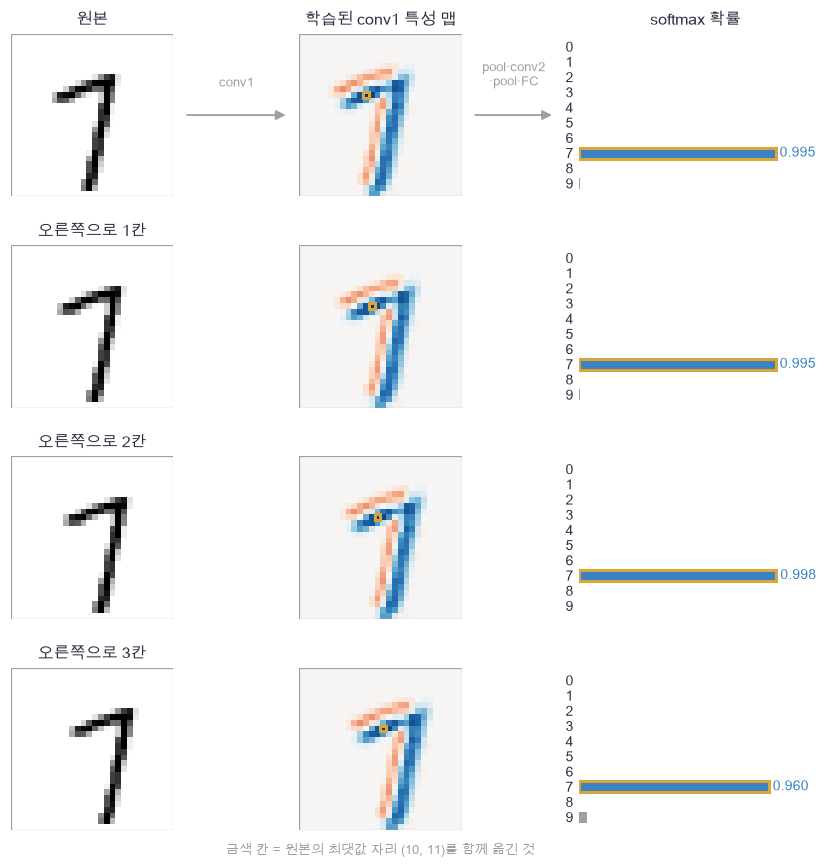

In [47]:
plot_shift_response([x[0, 0] for x in shift_inputs], [m[shift_channel] for m in shift_maps], shift_probs, shift_pixels, shift_peak, 7)

🔍 **확인** · 특성 맵의 금색 칸은 원본의 최댓값 자리를 $d$칸 옮긴 곳이고, 무늬 전체가 그대로 따라갑니다. 위 출력의 이동 차이는 정확히 0입니다(등변). 오른쪽 확률은 네 줄 모두 7이 가장 크지만 그 차이는 작지 않습니다. 3칸 이동의 최대 logit 변화 4.47은 원본의 1등−2등 마진 5.44에 가까운 크기라 마진이 3.19로 줄고 $P(7)$도 0.995에서 0.960으로 내려갑니다. 풀링 구역의 경계와 펼침의 자리가 바뀌므로 logit까지 같을 수는 없습니다.
아래 구현은 이 계산을 함수로 적고, 고정 예시 10장 모두에서 1·2·3칸 이동의 등변 차이가 0인지와 예측이 유지되는 장수를 셉니다. 마진이 이만큼 줄어드는 만큼, 27쌍 중 1쌍에서는 예측이 실제로 바뀝니다.

In [48]:
def shift_response(X, p, d):
    """입력을 오른쪽으로 d칸 굴린 뒤 학습된 conv1 특성 맵과 logit. X: (1, 1, 28, 28), p: 파라미터 사전, d: 정수 → (maps: (6, 28, 28), logits: (10,))."""
    # 쓰는 것: conv_forward (📎 05 함수 셀) · lenet_forward (2절)
    X_shifted = np.roll(X, d, axis=3)                                 # 가로 축으로 d칸
    maps = conv_forward(X_shifted, p["K1"], p["c1"], 1, 2)[0][0]      # (6, 28, 28)
    logits = lenet_forward(X_shifted, p)[0][0]                        # (10,)
    return maps, logits

In [49]:
# 쓰는 것: mnist_examples, mnist_7 (📎 데이터 셀) · lenet_p (3절 학습 셀) · shift_maps, shift_logits (4절 이동 셀)
tested, kept = 0, 0
for image in mnist_examples:                                          # 고정 예시 10장
    ink_cols = np.flatnonzero(image.sum(axis=0))                      # 잉크가 있는 열 번호들. 첫 것이 왼쪽 여백, 27 − 마지막 것이 오른쪽 여백
    base_maps, base_logits = shift_response(image[None, None], lenet_p, 0)
    for d in (1, 2, 3):
        if ink_cols[0] < 2 or 27 - ink_cols[-1] - d < 2:              # 옮긴 뒤에도 잉크가 양쪽 가장자리에서 2칸(두른 0의 폭) 이상 떨어진 쌍만
            continue
        maps_d, logits_d = shift_response(image[None, None], lenet_p, d)
        np.testing.assert_allclose(maps_d, np.roll(base_maps, d, axis=2), rtol=0, atol=1e-12)   # 검산: 등변. 특성 맵이 정확히 d칸 옮겨짐(rtol=0이라 판정 폭은 1e−12뿐)
        tested += 1
        kept += int(logits_d.argmax() == base_logits.argmax())
np.testing.assert_allclose(shift_response(mnist_7, lenet_p, 3)[0], shift_maps[3])       # 검산: 위 그림 계산과 같은 함수
np.testing.assert_allclose(shift_response(mnist_7, lenet_p, 3)[1], shift_logits[3])       # 검산: logit도 위 그림 계산과 같음
assert tested == 27, "여백 조건을 만족하는 (장, 칸) 쌍은 27개여야 합니다 (숫자 2는 1칸까지, 5는 2칸까지)"
assert kept >= 0.8 * tested, "예측이 유지된 쌍이 80%는 넘어야 합니다"
print(f"등변 검산 통과 ({tested}쌍, 차이 < 1e−12) · 예측 유지 {kept}/{tested} · logit 변화의 크기는 위 출력 참고")

등변 검산 통과 (27쌍, 차이 < 1e−12) · 예측 유지 26/27 · logit 변화의 크기는 위 출력 참고


🔍 **확인** · 여백 조건을 만족하는 27쌍(숫자 2는 오른쪽 여백이 3열뿐이라 1칸까지, 5는 4열이라 2칸까지) 모두 옮긴 특성 맵이 원본을 굴린 것과 $10^{-12}$ 안에서 같습니다. 예측은 27쌍 중 대부분 유지되지만 전부라는 보장은 없고, 유지되더라도 logit 값은 달라집니다. 이것이 "등변인 합성곱 + 불변에 가까운 나머지"의 실제 모습입니다.
학습 데이터의 숫자 위치가 다양하면 선형층이 여러 자리를 함께 배우므로 불변에 더 가까워집니다. 이 성질을 구조로 보장하려면 위치 축을 완전히 없애는 전역 풀링 같은 장치가 필요합니다(이 노트북의 범위 밖).

### ✏️ 연습 4 · 굴린 특성 맵 비교

원본 특성 맵 `maps_base` `(F, H, W)`를 가로 축으로 `d`칸 굴린 것과, 옮긴 입력의 특성 맵 `maps_shifted`의 **최대 절대 차이**를 돌려주는 한 줄을 채우세요. 등변이면 0입니다. 검사는 손계산 하나와 4절의 학습된 특성 맵으로 합니다.

In [50]:
def exercise_rolled_gap(maps_base, maps_shifted, d):
    """연습 4: 등변성 검사 값. maps_base, maps_shifted: (F, H, W), d: 가로로 옮긴 칸 수 → 최대 절대 차이 (숫자)."""
    assert maps_base.shape == maps_shifted.shape, "두 특성 맵의 모양이 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: gap = |maps_shifted − maps_base를 가로 축(axis=2)으로 d칸 굴린 것|의 최댓값
    ### 힌트: np.roll(maps_base, d, axis=2). 4절 이동 셀의 map_gap 한 줄입니다
    raise NotImplementedError
    return gap

In [51]:
def check_rolled_gap(candidate):
    """(1, 2, 3) 손계산과 4절의 실제 특성 맵으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: shift_maps (4절 이동 셀)
    base = np.array([[[1., 2., 3.], [4., 5., 6.]]])                      # (1, 2, 3): 채널 1, 2×3
    moved = np.array([[[3., 1., 2.], [6., 4., 5.5]]])                    # 오른쪽으로 1칸 굴린 것에서 한 칸만 0.5 다름
    np.testing.assert_allclose(candidate(base, moved, 1), 0.5)          # 검산: 손계산. 최대 차이 0.5
    np.testing.assert_allclose(candidate(base, np.roll(base, 2, axis=2), 2), 0.)   # 검산: 정확히 굴린 것이면 0
    np.testing.assert_allclose(candidate(shift_maps[0], shift_maps[3], 3), 0., atol=1e-12)   # 검산: 4절의 학습된 특성 맵, 3칸
    assert candidate(shift_maps[0], shift_maps[3], 2) > 0.1, "칸 수를 잘못 굴리면 차이가 커야 합니다"
    print("굴린 특성 맵 비교: 손계산·4절 결과와 일치합니다.")

run_check(check_rolled_gap, exercise_rolled_gap, hint="gap = float(np.abs(maps_shifted - np.roll(maps_base, d, axis=2)).max())")

☐ exercise_rolled_gap: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: gap = float(np.abs(maps_shifted - np.roll(maps_base, d, axis=2)).max())


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
gap = float(np.abs(maps_shifted - np.roll(maps_base, d, axis=2)).max())
```

</details>

## 🔍 5. test 보고: 혼동 행렬과 가장 자신 있게 틀린 예

학습·검증에 쓰지 않은 test 10,000장을 **한 번** 통과시킵니다(15번 6절). 정확도 하나로 끝내지 않고, 정답(행) × 예측(열)의 혼동 행렬로 어느 숫자끼리 헷갈리는지, 그리고 가장 높은 확률로 틀린 8장을 봅니다. 이 숫자는 학습용 작은 규모(20,000장·3에폭)의 성능이며 벤치마크로 읽지 마세요.

> **용어** · **혼동 행렬(confusion matrix)**(15번 5절): 칸 $(a, b)$ = 정답이 $a$인데 $b$로 예측한 장수. 대각선이 맞힌 것이고, 대각선 합을 전체로 나누면 정확도입니다.

> **코드**
>
> - `np.add.at(C, (y, pred), 1)`: 쌍 (y[n], pred[n])마다 그 칸에 1을 더합니다. 같은 칸이 여러 번 나와도 모두 더해집니다(`C[y, pred] += 1`은 중복을 한 번만 셉니다).
> - `np.argsort(a)[::-1][:8]`: 작은 순서로 정렬한 번호를 뒤집어 큰 값부터 8개.
> - `np.trace(C)`: 대각선의 합. `np.diag(C)`: 대각선 원소들. `np.diag(np.diag(C))`: 대각선만 남기고 나머지를 0으로 한 행렬.
> - `a.ravel()`: 2차원을 한 줄로 편 것. `divmod(k, 10)`: 펼친 번호 k를 (행, 열) = (k // 10, k % 10)로 되돌립니다(`np.unravel_index`와 같은 뜻).

In [52]:
# 쓰는 것: mnist_X_test, mnist_y_test (📎 데이터 셀) · predict_logits, accuracy (3절) · lenet_p (3절 학습 셀)
test_logits = predict_logits(mnist_X_test, lenet_p)                             # (10000, 10)
test_pred = test_logits.argmax(axis=1)                                          # (10000,)
test_probs = np.exp(test_logits - test_logits.max(axis=1, keepdims=True))
test_probs /= test_probs.sum(axis=1, keepdims=True)                             # (10000, 10): softmax
test_accuracy = accuracy(test_logits, mnist_y_test)
assert test_accuracy > 0.95, "학습용 규모에서도 test 정확도가 95%는 넘어야 합니다"
test_confusion = np.zeros((10, 10), dtype=int)                                 # (10, 10): 행 정답, 열 예측
np.add.at(test_confusion, (mnist_y_test, test_pred), 1)
assert test_confusion.sum() == 10000, "혼동 행렬의 합은 test 장수여야 합니다"
np.testing.assert_allclose(np.trace(test_confusion) / 10000, test_accuracy)   # 검산: 대각선 합 / N = 정확도
wrong = np.flatnonzero(test_pred != mnist_y_test)                              # 틀린 장의 번호
confident_wrong = wrong[np.argsort(test_probs[wrong, test_pred[wrong]])[::-1][:8]]   # 틀린 것 중 예측 확률이 높은 8장
per_digit = np.diag(test_confusion) / test_confusion.sum(axis=1)               # (10,): 숫자별 정확도
print(f"test 정확도 {test_accuracy:.4f} (n=10000) · 틀린 장수 {len(wrong)} · 숫자별 정확도", per_digit)
off_diagonal = test_confusion - np.diag(np.diag(test_confusion))                # (10, 10): 대각선(맞힌 것)을 0으로 지운 혼동 행렬
top_pairs = np.argsort(off_diagonal.ravel())[::-1][:3]                            # 틀린 장수가 많은 칸 3개의 펼친 번호
print("가장 자주 헷갈린 쌍 (정답, 예측):", [divmod(int(k), 10) for k in top_pairs])

test 정확도 0.9800 (n=10000) · 틀린 장수 200 · 숫자별 정확도 [0.9837 0.9921 0.9797 0.9851 0.9695 0.9821 0.9896 0.963  0.9846 0.9703]
가장 자주 헷갈린 쌍 (정답, 예측): [(4, 9), (7, 9), (2, 8)]


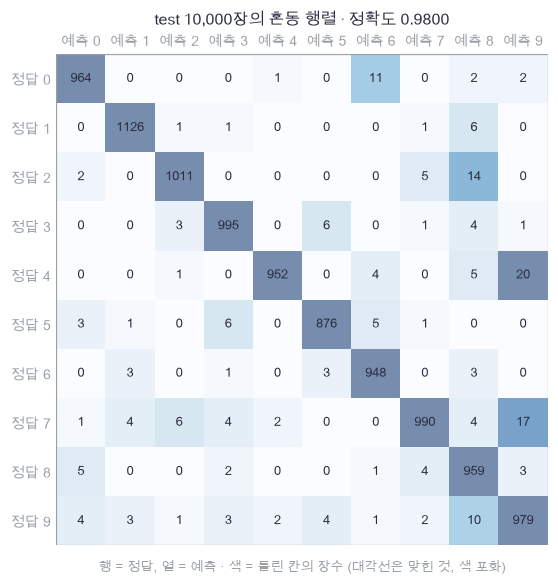

In [53]:
plot_confusion_matrix(test_confusion, test_accuracy)

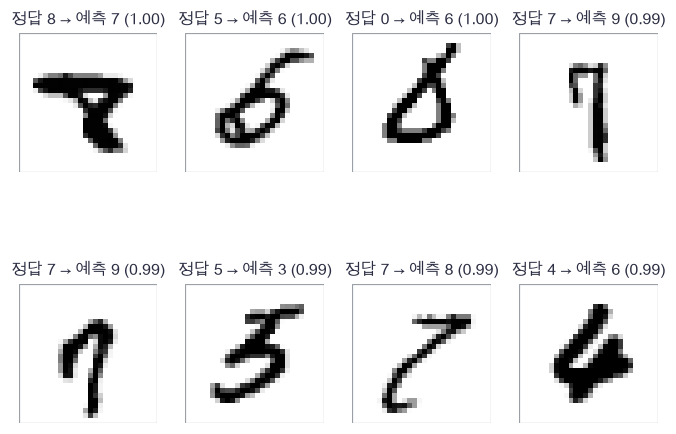

In [54]:
plot_wrong_examples(mnist_X_test[confident_wrong, 0],
                    [f"정답 {mnist_y_test[k]} → 예측 {test_pred[k]} ({test_probs[k, test_pred[k]]:.2f})" for k in confident_wrong])

🔍 **확인** · 대각선 밖의 색이 진한 칸이 자주 헷갈리는 쌍입니다. 위 출력의 세 쌍(4 → 9, 7 → 9, 2 → 8)은 모양이 실제로 닮은 숫자들입니다. 틀린 8장은 모델이 높은 확률을 주고도 틀린 것이라, 사람이 봐도 애매하게 쓴 것이 섞여 있습니다.
test 정확도는 검증 정확도와 비슷합니다. 검증으로 고른 설정(에폭 3, 학습률 0.002)을 test에 그대로 썼고 test로는 아무것도 고르지 않았기 때문에, 이 숫자를 "새 손글씨의 성능"으로 보고할 수 있습니다(15번 6절).

📎 **참고** · 원래 LeNet-5(LeCun 등, 1998)와 이 모델은 모양(conv 5×5 두 단, 완전 연결 120·84·10)이 같고 세부가 다릅니다. 원본은 32×32 입력(여기서는 28×28에 padding 2로 같은 28×28 특성 맵), 활성화 tanh(여기서는 ReLU), 학습하는 계수가 붙은 2×2 **평균** 풀링(여기서는 max pool), C3 층의 **부분 연결**(16개 커널이 6채널 중 일부만 봄; 여기서는 완전 연결 (16, 6, 5, 5)), 출력은 RBF 층(여기서는 softmax CE)입니다. 그래서 파라미터 수도 원본의 약 60,000개와 조금 다른 61,706개입니다. 미니배치 Adam과 He 초기화도 1998년에는 없던 절차입니다.

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 수용 영역 계산 (1절)

층 목록 `[(k, s), …]`를 지난 뒤 출력 한 칸이 보는 입력 창의 한 변 $r$과 누적 stride $j$를 점화식 $r\leftarrow r+(k-1)j$, $j\leftarrow j\,s$로 구하는 두 줄을 채우세요. 검사는 손계산 두 경우와 1절의 LeNet 층 목록, backward로 잰 창으로 합니다.

In [55]:
def exercise_receptive_field(layers):
    """연습 A: 층 목록 [(k, s), …]를 지난 뒤의 수용 영역 r과 누적 stride j. layers: (k, s) 튜플의 목록 → (r, j)."""
    r, j = 1, 1                                            # 입력: 한 칸이 한 칸을 보고, 한 칸 옆은 한 픽셀 옆
    for k, s in layers:
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: r에 (k − 1)·j를 더하고, 그다음 j에 s를 곱하기 (1절 점화식)
        ### 힌트: r = r + (k - 1) * j 다음 j = j * s. 순서가 중요합니다 (r을 먼저, 이전 층의 j로)
        raise NotImplementedError
    return r, j

In [56]:
def check_receptive_field(candidate):
    """손계산 두 경우와 1절 LeNet 층 목록(receptive_field·backward로 잰 창)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: receptive_field, LENET_LAYERS (1절) · rf_box (1절 수용 영역 셀)
    assert candidate([(3, 1), (3, 1)]) == (5, 1), "3×3 두 단(stride 1)이면 r = 1 + 2 + 2 = 5, j = 1이어야 합니다"
    assert candidate([(3, 2), (3, 1)]) == (7, 2), "첫 층 stride 2면 둘째 층의 이웃 한 칸이 입력 2픽셀: r = 3 + 2·2 = 7, j = 2"
    lenet_ks = [(k, s) for k, s, _ in LENET_LAYERS]
    assert candidate(lenet_ks) == (16, 4), "LeNet 네 층 뒤 r = 16, j = 4여야 합니다 (1절 표)"
    assert candidate(lenet_ks) == receptive_field(LENET_LAYERS), "1절 receptive_field와 같아야 합니다"
    assert candidate(lenet_ks)[0] == rf_box[2], "backward로 잰 입력 창의 한 변 16과 같아야 합니다"
    print("수용 영역: 손계산·1절 결과와 일치합니다.")

run_check(check_receptive_field, exercise_receptive_field, hint="r = r + (k - 1) * j 다음 줄에 j = j * s")

☐ exercise_receptive_field: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: r = r + (k - 1) * j 다음 줄에 j = j * s


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
r = r + (k - 1) * j
j = j * s
```

</details>

### ✏️ 연습 B · conv 두 단 forward 조립 (2절)

첫 단(conv1 → ReLU → max pool)은 써 두었습니다. 둘째 단 두 줄, 즉 `P1`에 `K2`·`c2`를 padding 0으로 합성곱한 `Z2`와 ReLU 뒤 max pool한 `P2`를 채우세요. 검사는 2절 검산 셀의 `probe` 모델과 손으로 이은 7의 흐름으로 합니다.

In [57]:
def exercise_conv_stages(X, p):
    """연습 B: conv1(p=2) → ReLU → max pool → conv2(p=0) → ReLU → max pool. X: (N, 1, 28, 28), p: 파라미터 사전 → P2: (N, 16, 5, 5)."""
    Z1, _ = conv_forward(X, p["K1"], p["c1"], 1, 2)                    # (N, 6, 28, 28)
    P1, _ = pool_forward(np.maximum(Z1, 0), "max")                     # (N, 6, 14, 14)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z2 = P1에 K2·c2를 padding 0으로 합성곱 (모양 (N, 16, 10, 10)), P2 = ReLU 뒤 max pool (모양 (N, 16, 5, 5))
    ### 힌트: 위 두 줄에서 X → P1, K1 → K2, c1 → c2, padding 2 → 0. conv_forward·pool_forward는 (값, cache)를 돌려주므로 _로 받습니다.
    raise NotImplementedError
    return P2

In [58]:
def check_conv_stages(candidate):
    """2절 검산 셀의 probe 모델(캐시의 펼침 F)과 2절 흐름 셀의 7(trace_P2)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: probe_X, probe_p, probe_cache (2절 검산 셀) · trace_P2, trace_p (2절 흐름·검산 셀) · mnist_7 (📎 데이터 셀)
    P2_probe = candidate(probe_X, probe_p)
    assert P2_probe.shape == (2, 16, 5, 5), f"입력 2장이면 (2, 16, 5, 5)여야 하는데 {np.shape(P2_probe)}입니다"
    np.testing.assert_allclose(P2_probe.reshape(2, -1), probe_cache[7])   # 검산: 캐시의 펼침 F (2, 400) = P2를 편 것
    np.testing.assert_allclose(candidate(mnist_7, trace_p), trace_P2)      # 검산: 2절에서 손으로 이은 7의 pool2 특성 맵
    print("conv 두 단: lenet_forward의 캐시·손으로 이은 흐름과 일치합니다.")

run_check(check_conv_stages, exercise_conv_stages, hint="Z2, _ = conv_forward(P1, p['K2'], p['c2'], 1, 0) · P2, _ = pool_forward(np.maximum(Z2, 0), 'max')")

☐ exercise_conv_stages: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z2, _ = conv_forward(P1, p['K2'], p['c2'], 1, 0) · P2, _ = pool_forward(np.maximum(Z2, 0), 'max')


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z2, _ = conv_forward(P1, p["K2"], p["c2"], 1, 0)
P2, _ = pool_forward(np.maximum(Z2, 0), "max")
```

</details>

### ✏️ 연습 C · conv 편향의 기울기 (2절)

conv 편향 $c_f$는 채널 $f$의 **모든 표본·모든 자리**에 더해졌으므로 기울기는 그 채널의 상류 기울기를 모두 더한 $dc_f=\sum_{n,i,j}dZ_{n,f,i,j}$입니다. `dZ` `(N, F, oh, ow)`에서 축 0·2·3을 더해 `(F,)`를 만드는 한 줄을 채우세요. 05번 3절의 `db = G.sum(axis=0)`(행으로 편 뒤)과 같은 값입니다.

In [59]:
def exercise_conv_bias_grad(dZ):
    """연습 C: conv 편향의 기울기 dc_f = Σ_{n,i,j} dZ[n, f, i, j]. dZ: (N, F, oh, ow) → (F,)."""
    assert dZ.ndim == 4, "dZ는 (N, F, oh, ow) 4차원이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 표본·세로·가로 축(0, 2, 3)을 한꺼번에 더해 채널마다 숫자 하나 (모양 (F,))
    ### 힌트: axis에 축 세 개를 튜플로 줍니다. 05번 4절 손계산 셀의 .max(axis=(2, 3))처럼
    raise NotImplementedError
    return dc

In [60]:
def check_conv_bias_grad(candidate):
    """(2, 2, 2, 2) 손계산 하나와 난수 입력에서 conv_backward의 db로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: conv_forward, conv_backward (📎 05 함수 셀)
    example_dZ = np.array([[[[1., 2.], [3., 4.]], [[-1., 0.], [0., 1.]]],
                           [[[1., 1.], [1., 1.]], [[2., -2.], [0., 0.]]]])     # (2, 2, 2, 2): 표본 2, 채널 2, 2×2
    actual = candidate(example_dZ)
    assert np.shape(actual) == (2,), f"채널이 2개면 (2,)여야 하는데 {np.shape(actual)}입니다"
    np.testing.assert_allclose(actual, [14., 0.])                          # 검산: 채널 0은 (1+2+3+4)+(1+1+1+1), 채널 1은 (−1+0+0+1)+(2−2+0+0)
    rng_check = np.random.default_rng(59)
    X_c = rng_check.normal(size=(3, 2, 6, 6))
    K_c = rng_check.normal(size=(4, 2, 3, 3))
    Y_c, cache_c = conv_forward(X_c, K_c, np.zeros(4), 1, 1)
    G_c = rng_check.normal(size=Y_c.shape)                                 # (3, 4, 6, 6): 임의의 상류 기울기
    np.testing.assert_allclose(candidate(G_c), conv_backward(G_c, cache_c)[2])   # 검산: conv_backward의 db와 같음
    print("conv 편향 기울기: 손계산·conv_backward와 일치합니다.")

run_check(check_conv_bias_grad, exercise_conv_bias_grad, hint="dc = dZ.sum(axis=(0, 2, 3))")

☐ exercise_conv_bias_grad: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dc = dZ.sum(axis=(0, 2, 3))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dc = dZ.sum(axis=(0, 2, 3))
```

</details>

### ✏️ 연습 D · test 정확도 한 줄 (3절)

logit `(N, 10)`에서 행마다 가장 큰 자리를 예측으로 삼아 정답 `y`와 같은 비율을 돌려주는 한 줄을 채우세요. 검사는 손계산 하나와 5절의 test logit으로 합니다.

In [61]:
def exercise_accuracy(logits, y):
    """연습 D: 정확도 = logit이 가장 큰 숫자가 정답과 같은 비율. logits: (N, 10), y: (N,) → 숫자."""
    assert logits.shape[0] == len(y), "logit의 행 수와 정답 수가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 행마다 argmax(axis=1)를 취해 y와 비교한 True/False의 평균
    ### 힌트: np.mean(비교 결과). 3절 accuracy 함수의 한 줄입니다
    raise NotImplementedError
    return acc

In [62]:
def check_accuracy(candidate):
    """손계산 3장과 5절 test logit 10,000장으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: test_logits, test_accuracy (5절 test 셀) · mnist_y_test (📎 데이터 셀)
    example_logits = np.array([[0.1, 2.0, -1.0], [3.0, 0.0, 0.5], [0.0, 0.2, 0.1]])   # (3, 3): 예측 1, 0, 1
    example_y = np.array([1, 0, 2])                                                    # 정답. 셋째만 틀림
    np.testing.assert_allclose(candidate(example_logits, example_y), 2 / 3)           # 검산: 3장 중 2장
    np.testing.assert_allclose(candidate(test_logits, mnist_y_test), test_accuracy)   # 검산: 5절의 test 정확도
    print("정확도: 손계산·5절 결과와 일치합니다.")

run_check(check_accuracy, exercise_accuracy, hint="acc = np.mean(logits.argmax(axis=1) == y)")

☐ exercise_accuracy: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: acc = np.mean(logits.argmax(axis=1) == y)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
acc = np.mean(logits.argmax(axis=1) == y)
```

</details>

### 🔍 완성 예제 · 커널 수 (6, 16) → (4, 8)

커널을 conv1 4개, conv2 8개로 줄이면 conv2의 입력 채널이 4, 펼침이 $8\cdot5\cdot5=200$차원이 되어 $W_1$은 (200, 120)이어야 합니다. 초기화의 모양만 바뀌고 forward·backward 식은 같습니다. 파라미터 수를 공식으로 세고, 열 개 파라미터를 40자리씩 뽑아 중심차분으로 검산한 뒤, 두 모델을 같은 조건(5,000장·1에폭)으로 짧게 학습해 검증 정확도를 비교합니다.

In [63]:
def init_lenet_filters(filters1, filters2, seed=503):
    """커널 수를 바꾼 LeNet 파라미터 사전 (He 초기화). conv2의 입력 채널과 펼침 차원 filters2·25가 함께 바뀝니다.
    filters1, filters2: conv1·conv2의 커널 수 → init_lenet과 같은 키의 사전."""
    rng_v = np.random.default_rng(seed)
    flat_dim = filters2 * 5 * 5                                       # 펼침 차원 (5×5 특성 맵 filters2장)
    return {"K1": rng_v.normal(size=(filters1, 1, 5, 5)) * np.sqrt(2 / 25), "c1": np.zeros(filters1),
            "K2": rng_v.normal(size=(filters2, filters1, 5, 5)) * np.sqrt(2 / (filters1 * 25)), "c2": np.zeros(filters2),
            "W1": rng_v.normal(size=(flat_dim, 120)) * np.sqrt(2 / flat_dim), "b1": np.zeros(120),
            "W2": rng_v.normal(size=(120, 84)) * np.sqrt(2 / 120), "b2": np.zeros(84),
            "W3": rng_v.normal(size=(84, 10)) * np.sqrt(1 / 84), "b3": np.zeros(10)}

In [64]:
# 쓰는 것: probe_X (2절 검산 셀) · sampled_gradient (2절) · lenet_forward, lenet_backward (2절)
variant_p = init_lenet_filters(4, 8)
n_variant = 4 * 25 + 4 + 8 * (4 * 25) + 8 + 200 * 120 + 120 + 120 * 84 + 84 + 84 * 10 + 10   # 층별 공식 (1절과 같은 꼴)
assert sum(v.size for v in variant_p.values()) == n_variant, "공식으로 센 파라미터 수와 배열 원소 수가 같아야 합니다"
for key in ("c1", "c2", "b1", "b2", "b3"):
    variant_p[key] = np.random.default_rng(506).normal(size=variant_p[key].shape) * 0.1   # 2절과 같은 이유로 편향도 난수
variant_logits, variant_cache = lenet_forward(probe_X, variant_p)
variant_G = np.random.default_rng(507).normal(size=variant_logits.shape)
variant_dX, variant_grads = lenet_backward(variant_G, variant_cache, variant_p)


def variant_scalar():
    """검사기용: 스칼라 L = Σ logits ⊙ G (커널 4·8 모델)."""
    return float(np.sum(lenet_forward(probe_X, variant_p)[0] * variant_G))


rng_variant = np.random.default_rng(508)
variant_errors = {}
for key, value in variant_p.items():                                  # 열 개 파라미터 모두 40자리씩
    sample_idx = rng_variant.choice(value.size, min(40, value.size), replace=False)
    variant_errors[key] = rel_error(variant_grads[key].reshape(-1)[sample_idx], sampled_gradient(variant_scalar, value, sample_idx))
assert variant_cache[7].shape == (2, 200), "커널 8개면 펼침이 8 × 5 × 5 = 200차원이어야 합니다"
assert max(variant_errors.values()) < 1e-6, "구조를 바꿔도 모든 기울기의 상대오차가 1e−6 아래여야 합니다"
print(f"커널 (4, 8): 파라미터 {n_variant:,} (원래 61,706) · 펼침 {variant_cache[7].shape[1]}차원 · 최대 상대오차 {max(variant_errors.values()):.2e}")

커널 (4, 8): 파라미터 36,046 (원래 61,706) · 펼침 200차원 · 최대 상대오차 5.21e-09


In [65]:
# 쓰는 것: mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid (📎 데이터 셀) · init_lenet (2절) · train_lenet (3절)
compare_p = {"(6, 16)": init_lenet(509), "(4, 8)": init_lenet_filters(4, 8, 509)}
compare_acc = {}
for name, params in compare_p.items():                                # 같은 5,000장·1에폭·같은 배치 순서(seed)
    history_v = train_lenet(params, mnist_X_train[:5000], mnist_y_train[:5000], mnist_X_valid, mnist_y_valid, epochs=1, seed=510)
    compare_acc[name] = history_v["valid_acc"][-1]
assert compare_acc["(4, 8)"] > 0.85, "커널을 줄여도 1에폭 뒤 검증 정확도가 85%는 넘어야 합니다"
print("5,000장·1에폭 뒤 검증 정확도:", {name: round(acc, 4) for name, acc in compare_acc.items()}, "· 학습용 작은 규모의 비교입니다")

에폭 1: 스텝 79 · 마지막 배치 CE 0.645 · 검증 정확도 0.9345


에폭 1: 스텝 79 · 마지막 배치 CE 0.819 · 검증 정확도 0.9205
5,000장·1에폭 뒤 검증 정확도: {'(6, 16)': 0.9345, '(4, 8)': 0.9205} · 학습용 작은 규모의 비교입니다


🔍 **확인** · 커널 수를 바꾸면 파라미터 수와 펼침 차원이 공식대로 바뀌고, 중심차분 검산도 그대로 통과합니다. 5,000장·1에폭의 짧은 학습에서 두 모델의 검증 정확도 차이는 크지 않습니다. 작은 문제에서는 커널 수보다 학습량이 먼저 성능을 정합니다. 커널 수의 효과를 제대로 보려면 15번 4절처럼 seed를 여러 개 두고 에폭도 늘려야 합니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** padding 2가 왜 5×5 창에서 크기를 지키는지, 두 단 뒤 한 칸이 왜 입력 16픽셀을 보는지 말할 수 있나요? → 1절
- **수식:** 다섯 층의 backward를 어느 순서로 어떤 식(선형층 세 식, ReLU 도함수, reshape 되돌리기, pool·conv backward)으로 부르는지 쓸 수 있나요? → 2절
- **구현:** 에폭·배치·Adam 루프를 쓰고 검증 정확도를 언제 재며 test를 언제 보는지 정할 수 있나요? → 3절
- **변형:** 커널 수를 바꿔도 모양·중심차분을 통과시키고, 이동에 대한 등변(정확히 같음)과 불변(거의 같음)을 수치로 구분할 수 있나요? → 2·4절

다음은 [06 RNN](06_rnn.ipynb)입니다. 이미지의 **위치**에 공유한 가중치를 시간의 **단계**에 공유해 봅니다.

📎 [LeCun 등, 1998](https://bottou.org/papers/lecun-98h)이 LeNet-5의 원전입니다. 이 노트북의 모델은 그 모양을 따르되 활성화·풀링·출력층·학습 절차가 다른 학습용 구성이며, 논문 결과의 재현 실험은 아닙니다.